In [533]:
import numpy as np
import pandas as pd
from utils.utils import discretizar, conservar_filas_con_n_no_nulos, get_filas_con_n_nulos, eliminar_duplicados, convertir_enteros_a_fecha
from matplotlib import pyplot as plt

from utils.load_data import load_excelfile, load_databases
from utils.estadisticas import mostrar_frecuencias, mostrar_unicos, mostrar_rango, mostrar_valores_nulos, \
                               mostrar_duplicados, graficar_segun_fecha

from utils.IAE import filtrar_IAES_por_fecha_registro, agregar_tipo_prestador_IAE, guardar_prestadores, acondicionar_atributo_metodo, \
                      agregar_categoria_metodo, acondicionar_IAE_PREVIO, calcular_y_agregar_campo_edad, acondicionar_campo_DECISION, \
                      agregar_campo_DECISION, agregar_si_intentos_en_CDE, corregir_fechas_enteras_prestadores, acondicionar_campos_prestadores, \
                      acondicionar_CONCURRIO, acondicionar_campo_agendo_consulta_en_7dias, agregar_si_es_IAE, agregar_si_tiene_fecha_registro
 
from utils.CDE import conciden_fechas_nacimiento_digitadas_y_calculadas, agregar_datos_CDE_en_IAE, \
                      agregar_atributo_CAT_SUI, argegar_atributo_CAT_MCEXSUI
from utils.agregado import agregar_base_intentos, agregar_campo, personas_con_IAE_no_presentes_en_CDE, personas_en_CDE_sin_IAE, \
                           agregar_IAE_PREVIO_corregido, personas_con_IAE_no_presentes_en_CNV, personas_en_CNV_sin_IAE, \
                        personas_con_IAE_no_presentes_en_RUCAF, personas_en_RUCAF_sin_IAE, personas_con_IAE_no_presentes_en_SHARPS, \
                        personas_en_SHARPS_sin_IAE, personas_con_IAE_no_presentes_en_SIV, personas_en_SIV_sin_IAE

from utils.CNV import esta_persona_en_CNV, agregar_datos_hijos_cuando_intento, agregar_datos_CNV_cuando_intento, \
                      incluir_otro_progrenitor, esta_nro_rese_en_IAE
from utils.RUCAF import agregar_datos_RUCAF_en_IAE
from utils.SHARP import esta_persona_en_SHARPS
from utils.SIV import agregar_campos_SIV
from utils.EH import agregar_datos_EH_cuando_intento

from datetime import datetime

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [534]:
# configuración
dataset = 2 # 1 primera entrega, 2 segunda entrega

campo_decision = 'DECISION' if dataset==2 else 'DECISIÓN'
campo_nacimiento = 'FECHA NACIMIENTO' if dataset==2 else 'NACIMIENTO'
campo_prestador = 'PRESTADOR' if dataset==2 else 'PRESTADOR RECODIFICADO'

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

In [535]:
archivo_primera_entrega = "/home/carbajal/Documents/SaludMental/Datos recibidos en primer instancia.xlsx"
archivo_segunda_entrega ='/home/carbajal/Documents/SaludMental/2da entrega 20260210/Planilla completa.xlsx'
archivo = archivo_primera_entrega if dataset==1 else archivo_segunda_entrega

In [536]:
# Levantar las bases. La segunda entrega tiene la base de egresos hospitalarios que no tiene la primera
if dataset ==1:
       df_IAE, df_IAE_CDE, df_IAE_CNV, df_IAE_RUCAF, df_IAE_SHARPS, df_IAE_SIV = load_databases(archivo, dataset)
elif dataset==2:
       df_IAE, df_IAE_CDE, df_IAE_CNV, df_IAE_RUCAF, df_IAE_SHARPS, df_IAE_SIV, df_IAE_EH = load_databases(archivo, dataset)


['IAE', 'CDE', 'CNV', 'EH', 'SIV', 'SHARPS', 'IAE_RUCAF', 'Sheet1']


In [537]:
#df_julio = df_IAE[(df_IAE['REGISTRO'] >= '2023-07-01') & (df_IAE['REGISTRO'] < '2023-08-01')]
df_julio = filtrar_IAES_por_fecha_registro(df_IAE, '2023-07-01', '2023-08-01')
df_julio

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,AGENDO NUEVA CONSULTA,FECHA DE NUEVA CONSULTA,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO
31,2948.0,76e96691329d077b639f4cf81f9f1fc8b053ff0b432b64...,NaN,NaN,Femenino,1968-11-01 00:00:00,RESUELTO,CAAMEPA IAMPP,NaN,2023-07-06,...,NO,4.0,31/07/2023 COMITÉ,SI,45133,Valentina Acosta,NaN,NaN,NaN,NaN
9856,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10129,NaN,7834576937f411029f97e22a9d01beaf1deeaed535d966...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12446,NaN,157070a400e8b90298340bf79ec515e88bd9dd51cd3cd9...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13180,NaN,1e939367f837a635b53b90c792936155446754bc746935...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19798,NaN,829f10b79b9295fb6ee6c4ec368046ebb570821374cdeb...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19829,NaN,a9b0bcabb1a8449e602a1f18d42686868074147f180a84...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19830,NaN,88602fbb9159e2afbb65e617fecc20ab79cb586c4452a0...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19861,NaN,efe30149fdbd423b75779dae5f73d368e0b528d7530de3...,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2023-07-25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Análisis de la base de IAE_CDE  (Certificados de defunción)

In [538]:
df_IAE_CDE.shape  # primera versión tenía 270 filas, ahora 4678

(4678, 16)

In [539]:
#df_IAE_CDE = df_IAE_CDE.dropna(thresh=3) # si tiene al menos tres valores no nulos me quedo con las filas
df_IAE_CDE = conservar_filas_con_n_no_nulos(df_IAE_CDE, n=3)


La base tenía 4678 filas. Luego de eliminar las filas con al menos 3 campos nulos quedaron 4678 filas


In [540]:
df_IAE_CDE.keys()

Index(['cedula', 'fecha_defuncion', 'causa_basica_muerte_valor',
       'causa_basica_muerte_descripcion', 'lugar_ocurrencia',
       'lugar_ocurrencia_detalle', 'departamento_ocurrencia',
       'edad_fallecimiento_calculada', 'edad_fallecimiento_digitada',
       'estado_civil', 'etnia', 'mayor_nivel_educacion',
       'institucion_fallecio', 'es_motivo_externo', 'motivo_externo',
       'motivo_externo_desc'],
      dtype='object')

In [541]:
df_IAE_CDE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4678 entries, 0 to 4677
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   cedula                           4678 non-null   object        
 1   fecha_defuncion                  4678 non-null   datetime64[ns]
 2   causa_basica_muerte_valor        4663 non-null   object        
 3   causa_basica_muerte_descripcion  4663 non-null   object        
 4   lugar_ocurrencia                 4678 non-null   object        
 5   lugar_ocurrencia_detalle         305 non-null    object        
 6   departamento_ocurrencia          4677 non-null   object        
 7   edad_fallecimiento_calculada     4667 non-null   float64       
 8   edad_fallecimiento_digitada      4668 non-null   float64       
 9   estado_civil                     4670 non-null   object        
 10  etnia                            4678 non-null   object     

In [542]:
#np.sum(df_IAE_CDE.duplicated()) # no hay duplicados
mostrar_duplicados(df_IAE_CDE)

La base tiene 0 filas duplicadas


In [543]:
if dataset==2: # la variable etnia está solo en la segunda entrega
    df_IAE_CDE['etnia'].value_counts()

In [544]:
if dataset==2: # la variable etnia está solo en la segunda entrega
    df_IAE_CDE['institucion_fallecio'].value_counts()

In [545]:
#df_IAE_CDE['motivo_externo'].value_counts()

In [546]:
#len(df_IAE['CEDULA'].unique())
mostrar_unicos(df_IAE,'CEDULA')

CEDULA tiene 16666 valores únicos.
['75b770ddbd1a43188f867d9ef8df0980412cb32b12374c03b6ab0e61e3ba43c4'
 'f5138e15e53b4df18a439fd908b90d42c88c708280daac7c76f09ff8213fb011'
 '919938e34174fd08e1fd49e678fc985160d058c6ea74d49c0ffe04806fa7919d' ...
 '169d68340bd6eab354ec7ce8ea1d7f6dad739167bb3bf47dc703d044be41e399'
 'fb411d4bf124deb8bffd3b6c1265a7ca09fab1dfc92af1c0c30b9d6ff08fb8cc'
 '8bf49c12b8ffc3a9bcd4063ca67f8cd2a71f7a1afa422958a74b877cdede2d56']


In [547]:
conciden_fechas_nacimiento_digitadas_y_calculadas(df_IAE_CDE)

Las fechas de nacimineto digitadas y calculadas coinciden en 4643 de 4678 casos


In [548]:
df_IAE_CDE[df_IAE_CDE['edad_fallecimiento_calculada']==0]

,cedula,fecha_defuncion,causa_basica_muerte_valor,causa_basica_muerte_descripcion,lugar_ocurrencia,lugar_ocurrencia_detalle,departamento_ocurrencia,edad_fallecimiento_calculada,edad_fallecimiento_digitada,estado_civil,etnia,mayor_nivel_educacion,institucion_fallecio,es_motivo_externo,motivo_externo,motivo_externo_desc
1488,508d9a741f6e92c8ea1c1c6c4be5b9bea4c4fce106d95c...,2023-09-07,W750,SOFOCACIÓN Y ESTRANGULAMIENTO ACCIDENTAL EN LA...,DOMICILIO,NaN,AR,0.0,0.0,NaN,BLANCA,NaN,NaN,S,OTRO,"lactante que dormia con sus padres , y entorno..."
2762,96ee8cb90b980ccf94009668bea37a56fa7ef92a8dc762...,2023-07-22,W144,"CAÍDA DESDE UN ÁRBOL, CALLES Y CARRETERAS",CENTRO ASISTENCIAL,NaN,MO,0.0,0.0,NaN,BLANCA,NaN,145.0,S,ACCIDENTE,traumatismo de craneo por caida de rama de arbol
3078,ab26547fad7357cee3286ee221a300c59a6a9455c9646c...,2023-10-29,X599,EXPOSICIÓN A FACTORES NO ESPECIFICADOS QUE CAU...,DOMICILIO,NaN,RV,0.0,0.0,NaN,BLANCA,NaN,NaN,S,ACCIDENTE,NaN
3374,bcc139731f614245970c5d1018c055c21f754ffdb8147d...,2025-06-18,W840,"OBSTRUCCIÓN NO ESPECIFICADA DE LA RESPIRACIÓN,...",DOMICILIO,NaN,CO,0.0,0.0,NaN,BLANCA,NaN,NaN,S,ACCIDENTE,NaN
3867,d725bc0cfba3ab2fc3903d51284b8b18086a196ac3a62f...,2024-02-06,W809,INHALACIÓN E INGESTIÓN DE OTROS OBJETOS QUE CA...,CENTRO ASISTENCIAL,NaN,CO,0.0,0.0,NaN,BLANCA,NaN,65.0,N,NaN,NaN
4108,e22d1f526d36e3b56c494b1843bd468487b05a0a752934...,2023-06-07,W799,INHALACIÓN E INGESTIÓN DE ALIMENTO QUE CAUSA O...,CENTRO ASISTENCIAL,NaN,MO,0.0,0.0,NaN,SE DESCONOCE,NaN,117.0,N,NaN,NaN


In [549]:
#df_IAE_CDE['lugar_ocurrencia'].value_counts()
mostrar_frecuencias(df_IAE_CDE,'lugar_ocurrencia')

lugar_ocurrencia
DOMICILIO                2110
CENTRO ASISTENCIAL       1609
OTRO                      480
VÍA PÚBLICA               295
TRABAJO                    67
CASA DE SALUD/ASILO        65
CÁRCEL                     44
AGUAS INTERNACIONALES       4
SE DESCONOCE                4
Name: count, dtype: int64


In [550]:
#np.sum(df_IAE_CDE['cedula'].isnull()) # no hay campos vacíos en las cédulas
mostrar_valores_nulos(df_IAE_CDE,'cedula')

cedula tiene 0 valores nulos


In [551]:
df_IAE_CDE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4678 entries, 0 to 4677
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   cedula                           4678 non-null   object        
 1   fecha_defuncion                  4678 non-null   datetime64[ns]
 2   causa_basica_muerte_valor        4663 non-null   object        
 3   causa_basica_muerte_descripcion  4663 non-null   object        
 4   lugar_ocurrencia                 4678 non-null   object        
 5   lugar_ocurrencia_detalle         305 non-null    object        
 6   departamento_ocurrencia          4677 non-null   object        
 7   edad_fallecimiento_calculada     4667 non-null   float64       
 8   edad_fallecimiento_digitada      4668 non-null   float64       
 9   estado_civil                     4670 non-null   object        
 10  etnia                            4678 non-null   object     

In [552]:
#df_IAE_CDE['causa_basica_muerte_valor'].unique()
mostrar_unicos(df_IAE_CDE,'causa_basica_muerte_valor')
mostrar_unicos(df_IAE_CDE,'lugar_ocurrencia')

causa_basica_muerte_valor tiene 381 valores únicos.
['X707' 'Y260' 'X849' 'X599' 'R961' 'Y249' 'X708' 'W809' 'W124' 'W735'
 'X590' 'X450' 'Y344' 'X049' 'X700' 'X744' 'V445' 'X740' 'W740' 'W019'
 'W014' 'X701' 'W748' 'W780' 'X748' 'Y218' 'X640' 'X319' 'X704' 'Y349'
 'Y261' 'R99' 'B209' 'X831' 'X649' 'W789' 'X705' 'W744' 'N179' 'X645'
 'X709' 'X000' 'W844' 'W176' 'X449' 'X659' 'W800' 'X800' 'B378' 'W849' nan
 'Y340' 'X714' 'X470' 'X610' 'W238' 'J449' 'X749' 'W206' 'W856' 'X718'
 'W798' 'X310' 'X680' 'W649' 'X840' 'W790' 'J189' 'W870' 'W100' 'X459'
 'X745' 'W060' 'W010' 'Y140' 'K746' 'W130' 'I219' 'W230' 'J849' 'W199'
 'W168' 'W698' 'X230' 'X200' 'F03' 'G931' 'W749' 'Y348' 'Y300' 'J81'
 'X732' 'X619' 'X760' 'X099' 'W840' 'W874' 'W200' 'W132' 'X702' 'X809'
 'J440' 'C169' 'X420' 'W700' 'C349' 'Y219' 'X730' 'X747' 'X737' 'X479'
 'W680' 'W879' 'J989' 'D689' 'I330' 'J459' 'X699' 'X780' 'I639' 'X719'
 'I500' 'C900' 'X429' 'X469' 'X670' 'W011' 'Y244' 'X781' 'C800' 'W794'
 'Y264' 'W799' 'X090' 'Y

In [553]:
#df_IAE_CDE['departamento_ocurrencia'].value_counts()
mostrar_frecuencias(df_IAE_CDE,'departamento_ocurrencia')

departamento_ocurrencia
MO    1922
CA     603
MA     268
CO     197
SA     157
PA     155
SJ     150
RV     134
TA     132
RO     123
CL     121
LA     109
SO     109
TT     108
DU     106
AR      91
RN      82
FD      75
FS      35
Name: count, dtype: int64


In [554]:
edades_digitadas = df_IAE_CDE["edad_fallecimiento_digitada"]
#print(edades_digitadas)
#print(len(edades_digitadas), edades_digitadas.min(), edades_digitadas.max())
mostrar_rango(df_IAE_CDE,"edad_fallecimiento_digitada")
#print('Valores nulos:',np.sum(edades_digitadas.isnull()))
mostrar_valores_nulos(df_IAE_CDE,"edad_fallecimiento_digitada")
#edades.value_counts()

El rango del atributo edad_fallecimiento_digitada es [0.0, 106.0]
edad_fallecimiento_digitada tiene 10 valores nulos


In [555]:
edades_calculadas = df_IAE_CDE["edad_fallecimiento_calculada"]
#print(edades_calculadas)
mostrar_rango(df_IAE_CDE,"edad_fallecimiento_calculada")

mostrar_valores_nulos(df_IAE_CDE,"edad_fallecimiento_calculada")

#print(np.sum(edades_calculadas==edades_digitadas))
conciden_fechas_nacimiento_digitadas_y_calculadas(df_IAE_CDE)

El rango del atributo edad_fallecimiento_calculada es [0.0, 106.0]
edad_fallecimiento_calculada tiene 11 valores nulos
Las fechas de nacimineto digitadas y calculadas coinciden en 4643 de 4678 casos


In [556]:
# algunos valores de CIE10 sacados de wikipedia, por ahora no se usan
# en esta base hay mas (R99, J189, E149, etc)


In [557]:
df_IAE_CDE = agregar_atributo_CAT_SUI(df_IAE_CDE)
df_IAE_CDE = argegar_atributo_CAT_MCEXSUI(df_IAE_CDE)

Hay 2181 filas de 4678 en la categoría CAT_SUI_
Hay 2067 filas de 4678 en la categoría CAT_MCEXSUI_


In [558]:
#df_IAE_CDE['CAT_MCEXSUI_'] = df_IAE_CDE['causa_basica_muerte_valor'].apply( lambda x : 1 if str(x)[:3] in CAT_MCEXSUI else 0) 

In [559]:
#df_IAE_CDE['causa_basica_muerte_valor'].value_counts()
mostrar_frecuencias(df_IAE_CDE, 'causa_basica_muerte_valor')

causa_basica_muerte_valor
X700    1187
X590     611
X599     399
X740     246
W849     186
        ... 
W235       1
X618       1
W856       1
B378       1
X659       1
Name: count, Length: 380, dtype: int64


In [560]:
#len(df_IAE_CDE['causa_basica_muerte_valor'].unique())  #En el CIE10 hay 1170 categorías, 
#En el CIE10 hay 1170 categorías
# En la primera entrega se usan acá se usan 110 + nan.  
# En la segunda entrega se usan 38
mostrar_unicos(df_IAE_CDE, 'causa_basica_muerte_valor')

causa_basica_muerte_valor tiene 381 valores únicos.
['X707' 'Y260' 'X849' 'X599' 'R961' 'Y249' 'X708' 'W809' 'W124' 'W735'
 'X590' 'X450' 'Y344' 'X049' 'X700' 'X744' 'V445' 'X740' 'W740' 'W019'
 'W014' 'X701' 'W748' 'W780' 'X748' 'Y218' 'X640' 'X319' 'X704' 'Y349'
 'Y261' 'R99' 'B209' 'X831' 'X649' 'W789' 'X705' 'W744' 'N179' 'X645'
 'X709' 'X000' 'W844' 'W176' 'X449' 'X659' 'W800' 'X800' 'B378' 'W849' nan
 'Y340' 'X714' 'X470' 'X610' 'W238' 'J449' 'X749' 'W206' 'W856' 'X718'
 'W798' 'X310' 'X680' 'W649' 'X840' 'W790' 'J189' 'W870' 'W100' 'X459'
 'X745' 'W060' 'W010' 'Y140' 'K746' 'W130' 'I219' 'W230' 'J849' 'W199'
 'W168' 'W698' 'X230' 'X200' 'F03' 'G931' 'W749' 'Y348' 'Y300' 'J81'
 'X732' 'X619' 'X760' 'X099' 'W840' 'W874' 'W200' 'W132' 'X702' 'X809'
 'J440' 'C169' 'X420' 'W700' 'C349' 'Y219' 'X730' 'X747' 'X737' 'X479'
 'W680' 'W879' 'J989' 'D689' 'I330' 'J459' 'X699' 'X780' 'I639' 'X719'
 'I500' 'C900' 'X429' 'X469' 'X670' 'W011' 'Y244' 'X781' 'C800' 'W794'
 'Y264' 'W799' 'X090' 'Y

In [561]:
## La base de defunciones no dice el prestador donde se produjo el deceso

In [562]:


# Agrupar edades de a 5 
df_IAE_CDE = discretizar(df_IAE_CDE, "edad_fallecimiento_calculada", "grupo edades_", 5)

# Análisis de la base de IAE  

In [563]:
df_IAE.shape   # 10428 intentos

(19884, 29)

In [564]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19884 entries, 0 to 19883
Data columns (total 29 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   ID                                         15586 non-null  float64       
 1   CEDULA                                     19873 non-null  object        
 2   NOMBRE                                     0 non-null      float64       
 3   APELLIDO                                   0 non-null      float64       
 4   PERSONA                                    19351 non-null  object        
 5   FECHA NACIMIENTO                           15047 non-null  object        
 6   DECISION                                   9710 non-null   object        
 7   PRESTADOR                                  15587 non-null  object        
 8   ESTABLECIMIENTO REGISTRO                   12498 non-null  object        
 9   REGISTRO         

In [565]:
df_IAE[df_IAE['CEDULA'].isna()]

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,AGENDO NUEVA CONSULTA,FECHA DE NUEVA CONSULTA,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO
770,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9856,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15795,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-02-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16802,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-08-15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16826,NaN,NaN,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2025-07-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17315,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18379,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2024-09-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18913,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-05-23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18933,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2024-11-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [566]:
#df_IAE[df_IAE['CEDULA'].isna()]
mostrar_valores_nulos(df_IAE,'CEDULA')

CEDULA tiene 11 valores nulos


In [567]:
#df_IAE = df_IAE.dropna(thresh=4) # se elimina una fila que tenía casi todo Nan (mas de 3)
#df_IAE.shape
df_IAE = conservar_filas_con_n_no_nulos(df_IAE, 4) 

La base tenía 19884 filas. Luego de eliminar las filas con al menos 4 campos nulos quedaron 19873 filas


In [568]:
df_IAE.head()

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,AGENDO NUEVA CONSULTA,FECHA DE NUEVA CONSULTA,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO
0,895.0,75b770ddbd1a43188f867d9ef8df0980412cb32b12374c...,NaN,NaN,Femenino,2009-09-01 00:00:00,NO CUMPLE PROTOCOLO,UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA,NaN,2023-01-24,...,NO,NaN,NO,NaN,NaN,valentina Acosta,NaN,NaN,NaN,NaN
1,1507.0,f5138e15e53b4df18a439fd908b90d42c88c708280daac...,NaN,NaN,Femenino,2002-09-01 00:00:00,RESUELTO,CAMEC,NaN,2023-03-14,...,SI,45021.0,NaN,NaN,NaN,LIC ROMANO,,NaN,NaN,NaN
2,2677.0,919938e34174fd08e1fd49e678fc985160d058c6ea74d4...,NaN,NaN,Masculino,2006-05-01 00:00:00,RESUELTO,MEDICA URUGUAYA MUCAM,NaN,2023-06-08,...,NaN,NaN,NO,NaN,NaN,LIC ROMANO,DRA FERNANDEZ,NaN,NaN,NaN
3,2804.0,6fb148c1f5d374e972746773f234955641ffee740f61f2...,NaN,NaN,Femenino,1952-07-01 00:00:00,PENDIENTE RESPUESTA,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,SANATORIO JUAN PABLO II,2023-06-19,...,NaN,NaN,NaN,NaN,NaN,Valentina Acosta,Envio email al circulo solicitando informacion.,NaN,NaN,NaN
4,2805.0,182eafb797ccb4f8a55b932370740d5ab89093978223ae...,NaN,NaN,Femenino,1996-07-01 00:00:00,PENDIENTE RESPUESTA,CUDAM,CENTRAL,2023-06-19,...,NaN,NaN,PEND,NaN,NaN,Valentina Acosta,Me comunico con supervisora de archivos en bus...,NaN,NaN,NaN


In [569]:
print(df_IAE.loc[df_IAE['CEDULA']=='e1be0faa774f043efdd0942cb03ee79a0c626167b05d47b055ae0bf6018cda96',['FECHA IAE','REGISTRO']])

       FECHA IAE   REGISTRO
1958  2024-03-01 2024-03-06
3706  2024-08-30 2024-09-03
4379  2024-10-10 2024-10-11
6543  2025-02-05 2025-02-11
6594  2025-02-12 2025-02-13
7869  2025-04-21 2025-04-28
8389  2025-05-31 2025-06-02
9090  2025-07-15 2025-07-21
9232  2025-07-17 2025-07-28
10280 2025-09-18 2025-09-22
11124 2025-10-30 2025-11-03
11486 2025-11-20 2025-11-21


In [570]:
if dataset==2:
    print(df_IAE.loc[df_IAE['REGISTRO'].isnull()*df_IAE['FECHA IAE'].isnull() ,['FECHA IAE','REGISTRO','CONCURRIO']])

      FECHA IAE REGISTRO CONCURRIO
12961       NaT      NaT       NaN


In [571]:
if dataset==2:
    df_IAE[df_IAE['ID']==5256]

In [572]:
df_IAE[df_IAE['CEDULA']=='a5c7dd631f96bdad252ff518e3dbbf711dfac499072845a12a2a4e1263cdb944']

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,AGENDO NUEVA CONSULTA,FECHA DE NUEVA CONSULTA,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO
12961,5256.0,a5c7dd631f96bdad252ff518e3dbbf711dfac499072845...,NaN,NaN,Femenino,1982-11-01 00:00:00,RESUELTO,GREMCA - GREMIAL MEDICA CENTRO ASISTENCIAL,NaN,NaT,...,NaN,NaN,NaN,NaN,SI,45302,Valentina Acosta,NaN,NaN,NaN


In [573]:
mostrar_frecuencias(df_IAE,'CEDULA')

CEDULA
e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a    16
228f1c59f6ccfc954920d227db9bf3a747fb989c06e1e817a9932777098e140f    13
15b386c21fa56d4187b20c7903269000505a596fbda3f62074b72822cffde86b    13
6f343891fb7d579858b87ecf0b6e8b44f1d15395822600355be8dcaae39c4362    12
e1be0faa774f043efdd0942cb03ee79a0c626167b05d47b055ae0bf6018cda96    12
                                                                    ..
8dbb4462902d4093cb9914105af2607b0240b45bfbbbc042806bd7a2c35c0660     1
bb15bbcc55540e176b92c82691a100b7f2ac69543183b4622cd79bdc3cf8a724     1
cf65782e4eb1ce87b5335fac88b8cd9b7c275e913661bb913cd710a867b723bc     1
8bf49c12b8ffc3a9bcd4063ca67f8cd2a71f7a1afa422958a74b877cdede2d56     1
1d695ce2c0ac60da4d59e890e1e36d96af23b50be11b6a91af5105f276a22a7b     1
Name: count, Length: 16665, dtype: int64


In [574]:
tiene_registro = ~df_IAE['REGISTRO'].isnull()
tiene_Fecha_IAE = ~df_IAE['FECHA IAE'].isnull()

In [575]:
(tiene_registro * tiene_Fecha_IAE).sum()

np.int64(11556)

In [576]:
(~tiene_registro * tiene_Fecha_IAE).sum()

np.int64(4030)

In [577]:
(tiene_registro * ~tiene_Fecha_IAE).sum()

np.int64(4286)

In [578]:
df_IAE = agregar_si_tiene_fecha_registro(df_IAE)
df_IAE = agregar_si_es_IAE(df_IAE)

15842 de las 19873 filas de la base IAE tienen fecha de registro
15586 de las 19873 filas de la base IAE son intentos


In [579]:
mostrar_valores_nulos(df_IAE,'CEDULA') # existen todas las cédulas
mostrar_frecuencias(df_IAE,'CEDULA')

CEDULA tiene 0 valores nulos
CEDULA
e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a    16
228f1c59f6ccfc954920d227db9bf3a747fb989c06e1e817a9932777098e140f    13
15b386c21fa56d4187b20c7903269000505a596fbda3f62074b72822cffde86b    13
6f343891fb7d579858b87ecf0b6e8b44f1d15395822600355be8dcaae39c4362    12
e1be0faa774f043efdd0942cb03ee79a0c626167b05d47b055ae0bf6018cda96    12
                                                                    ..
8dbb4462902d4093cb9914105af2607b0240b45bfbbbc042806bd7a2c35c0660     1
bb15bbcc55540e176b92c82691a100b7f2ac69543183b4622cd79bdc3cf8a724     1
cf65782e4eb1ce87b5335fac88b8cd9b7c275e913661bb913cd710a867b723bc     1
8bf49c12b8ffc3a9bcd4063ca67f8cd2a71f7a1afa422958a74b877cdede2d56     1
1d695ce2c0ac60da4d59e890e1e36d96af23b50be11b6a91af5105f276a22a7b     1
Name: count, Length: 16665, dtype: int64


In [580]:
#aa = df_IAE.dropna(thresh=5)
aa = conservar_filas_con_n_no_nulos(df_IAE, n=5)

La base tenía 19873 filas. Luego de eliminar las filas con al menos 5 campos nulos quedaron 19873 filas


In [581]:
#bad = df_IAE[df_IAE.isna().sum(axis=1) > 24]
bad = get_filas_con_n_nulos(df_IAE, n=24)
#bad = bad.dropna(axis=1, how='all')
bad

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO,tiene_registro_,es_IAE_
493,NaN,e8c474da07e0da4abcf929593a7198bb7bb269c75c2ef3...,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2023-11-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
551,NaN,6df43fd79182851d547b8eaf01a157d72b05aae6725647...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-03-22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
610,NaN,9de584a52b3e32a2955c85ca70bc05ce0902a2a311bd95...,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2025-06-27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
641,NaN,6d840ad2277fa8282bcc273b23ea0f3f5c5f7c7a1dda20...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2024-12-05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
841,NaN,0cced34f24b380bd55081bf4414cbbff56f63b56a49bad...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-11-03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19879,NaN,ca22ff093b04f0c7b98744c37337fabce487dcefeaebf3...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-01-28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
19880,NaN,c8426aa7f35f46523c1aded3048e5ca01179c5faf5131c...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-02-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
19881,NaN,169d68340bd6eab354ec7ce8ea1d7f6dad739167bb3bf4...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-09-03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
19882,NaN,fb411d4bf124deb8bffd3b6c1265a7ca09fab1dfc92af1...,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2025-10-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False


In [582]:
bad.keys()

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       'METODO', 'IAE PREVIO', 'FECHA IAE', 'FECHA SEGUIMIENTO',
       'FECHA LLAMADA PRESTADOR', 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO',
       'FECHA DE CONSULTA', 'CONCURRIO', 'SE LLAMO A USUARIO Y/O REFERENTE',
       'AGENDO NUEVA CONSULTA', 'FECHA DE NUEVA CONSULTA', 'INTERNACION',
       'FECHA ALTA', 'FECHA LLAMADA PRESTADOR.1', 'MSP', 'OBSERVACIONES',
       'UNNAMED: 26', 'FECHA DE LLAMADA AL PRESTADOR', 'MOTIVO',
       'tiene_registro_', 'es_IAE_'],
      dtype='object')

In [583]:
bad.index

Index([  493,   551,   610,   641,   841,   894,  1090,  1248,  1664,  1924,
       ...
       19874, 19875, 19876, 19877, 19878, 19879, 19880, 19881, 19882, 19883],
      dtype='int64', length=4286)

In [584]:
indices_malos = bad.index
indices_malos

Index([  493,   551,   610,   641,   841,   894,  1090,  1248,  1664,  1924,
       ...
       19874, 19875, 19876, 19877, 19878, 19879, 19880, 19881, 19882, 19883],
      dtype='int64', length=4286)

In [585]:
df_IAE.loc[indices_malos]

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO,tiene_registro_,es_IAE_
493,NaN,e8c474da07e0da4abcf929593a7198bb7bb269c75c2ef3...,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2023-11-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
551,NaN,6df43fd79182851d547b8eaf01a157d72b05aae6725647...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-03-22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
610,NaN,9de584a52b3e32a2955c85ca70bc05ce0902a2a311bd95...,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2025-06-27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
641,NaN,6d840ad2277fa8282bcc273b23ea0f3f5c5f7c7a1dda20...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2024-12-05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
841,NaN,0cced34f24b380bd55081bf4414cbbff56f63b56a49bad...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-11-03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19879,NaN,ca22ff093b04f0c7b98744c37337fabce487dcefeaebf3...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-01-28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
19880,NaN,c8426aa7f35f46523c1aded3048e5ca01179c5faf5131c...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-02-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
19881,NaN,169d68340bd6eab354ec7ce8ea1d7f6dad739167bb3bf4...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-09-03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
19882,NaN,fb411d4bf124deb8bffd3b6c1265a7ca09fab1dfc92af1...,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2025-10-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False


In [586]:
print(df_IAE.loc[indices_malos])

       ID                                             CEDULA  NOMBRE  \
493   NaN  e8c474da07e0da4abcf929593a7198bb7bb269c75c2ef3...     NaN   
551   NaN  6df43fd79182851d547b8eaf01a157d72b05aae6725647...     NaN   
610   NaN  9de584a52b3e32a2955c85ca70bc05ce0902a2a311bd95...     NaN   
641   NaN  6d840ad2277fa8282bcc273b23ea0f3f5c5f7c7a1dda20...     NaN   
841   NaN  0cced34f24b380bd55081bf4414cbbff56f63b56a49bad...     NaN   
...    ..                                                ...     ...   
19879 NaN  ca22ff093b04f0c7b98744c37337fabce487dcefeaebf3...     NaN   
19880 NaN  c8426aa7f35f46523c1aded3048e5ca01179c5faf5131c...     NaN   
19881 NaN  169d68340bd6eab354ec7ce8ea1d7f6dad739167bb3bf4...     NaN   
19882 NaN  fb411d4bf124deb8bffd3b6c1265a7ca09fab1dfc92af1...     NaN   
19883 NaN  8bf49c12b8ffc3a9bcd4063ca67f8cd2a71f7a1afa4229...     NaN   

       APELLIDO    PERSONA FECHA NACIMIENTO DECISION PRESTADOR  \
493         NaN   Femenino              NaN      NaN       NaN   
551

In [587]:
df_IAE.shape, aa.shape

((19873, 31), (19873, 31))

In [588]:
df_IAE[df_IAE['CEDULA'].isnull()]

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO,tiene_registro_,es_IAE_


## Duplicados IAE

In [589]:
df_IAE.shape[0]

19873

In [590]:
#df_IAE.drop_duplicates(inplace=True)  # en la primera entrega de datos 10 valores están duplicados y se eliminan
                                      # en la segunda entrega hay 2 valores están duplicados y se eliminan 
#df_IAE.shape
df_IAE = eliminar_duplicados(df_IAE)

Se eliminaron 2 filas duplicadas en la base. Ahora la base tiene 19871 filas.


In [591]:
mostrar_duplicados(df_IAE)

La base tiene 0 filas duplicadas


In [592]:
# En la entrega 1 hay 6 pares de IAE que difieren solo en los campos REGISTRO y/o ESTABLECIMIENTO REGISTRO (no hago nada con ellos)
# uno par ocurrió el mismo día
# En la entrega 2 hay 938 filas que difieren de otra solo en la cedula 
#cols_igual = [c for c in df_IAE.columns if c not in ['CEDULA']]
#duplicados = df_IAE[df_IAE.duplicated(subset=cols_igual, keep=False)]
#duplicados
mostrar_duplicados(df_IAE, ['CEDULA'])


La base tiene 938 filas duplicadas si no se consideran las diferencias en ['CEDULA']


In [593]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19871 entries, 0 to 19883
Data columns (total 31 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   ID                                         15584 non-null  float64       
 1   CEDULA                                     19871 non-null  object        
 2   NOMBRE                                     0 non-null      float64       
 3   APELLIDO                                   0 non-null      float64       
 4   PERSONA                                    19340 non-null  object        
 5   FECHA NACIMIENTO                           15045 non-null  object        
 6   DECISION                                   9710 non-null   object        
 7   PRESTADOR                                  15585 non-null  object        
 8   ESTABLECIMIENTO REGISTRO                   12496 non-null  object        
 9   REGISTRO              

In [594]:
if dataset==2:
    mostrar_frecuencias(df_IAE,'AGENDO NUEVA CONSULTA')

AGENDO NUEVA CONSULTA
SI           3125
NO            550
SI            451
si            105
NO             44
no             42
PEND           37
pend            4
?               1
pend            1
45863           1
BRASIL          1
pen             1
45079           1
PEND            1
PENDIENTE       1
Name: count, dtype: int64


In [595]:
#df_IAE['MOTIVO'].value_counts()
if dataset==2:
    mostrar_frecuencias(df_IAE,'MOTIVO')

MOTIVO
1.0        7
7.0        3
4.0        2
45100.0    1
45121.0    1
3.0        1
Name: count, dtype: int64


In [596]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19871 entries, 0 to 19883
Data columns (total 31 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   ID                                         15584 non-null  float64       
 1   CEDULA                                     19871 non-null  object        
 2   NOMBRE                                     0 non-null      float64       
 3   APELLIDO                                   0 non-null      float64       
 4   PERSONA                                    19340 non-null  object        
 5   FECHA NACIMIENTO                           15045 non-null  object        
 6   DECISION                                   9710 non-null   object        
 7   PRESTADOR                                  15585 non-null  object        
 8   ESTABLECIMIENTO REGISTRO                   12496 non-null  object        
 9   REGISTRO              

In [597]:
mostrar_unicos(df_IAE, 'CEDULA')

CEDULA tiene 16665 valores únicos.
['75b770ddbd1a43188f867d9ef8df0980412cb32b12374c03b6ab0e61e3ba43c4'
 'f5138e15e53b4df18a439fd908b90d42c88c708280daac7c76f09ff8213fb011'
 '919938e34174fd08e1fd49e678fc985160d058c6ea74d49c0ffe04806fa7919d' ...
 '169d68340bd6eab354ec7ce8ea1d7f6dad739167bb3bf47dc703d044be41e399'
 'fb411d4bf124deb8bffd3b6c1265a7ca09fab1dfc92af1c0c30b9d6ff08fb8cc'
 '8bf49c12b8ffc3a9bcd4063ca67f8cd2a71f7a1afa422958a74b877cdede2d56']


In [598]:
mostrar_frecuencias(df_IAE,'CEDULA') # en primera entrega dos personas con 10 intentos

CEDULA
e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a    16
228f1c59f6ccfc954920d227db9bf3a747fb989c06e1e817a9932777098e140f    13
15b386c21fa56d4187b20c7903269000505a596fbda3f62074b72822cffde86b    13
6f343891fb7d579858b87ecf0b6e8b44f1d15395822600355be8dcaae39c4362    12
e1be0faa774f043efdd0942cb03ee79a0c626167b05d47b055ae0bf6018cda96    12
                                                                    ..
8dbb4462902d4093cb9914105af2607b0240b45bfbbbc042806bd7a2c35c0660     1
bb15bbcc55540e176b92c82691a100b7f2ac69543183b4622cd79bdc3cf8a724     1
cf65782e4eb1ce87b5335fac88b8cd9b7c275e913661bb913cd710a867b723bc     1
8bf49c12b8ffc3a9bcd4063ca67f8cd2a71f7a1afa422958a74b877cdede2d56     1
1d695ce2c0ac60da4d59e890e1e36d96af23b50be11b6a91af5105f276a22a7b     1
Name: count, Length: 16665, dtype: int64


In [599]:
df_IAE[df_IAE['CEDULA']=='e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a']

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO,tiene_registro_,es_IAE_
1780,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01 00:00:00,RESUELTO,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2024-02-21,...,NaN,NaN,NO,NaN,Valentina Acosta,NaN,NaN,NaN,True,True
2606,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01 00:00:00,RESUELTO,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2024-06-25,...,NaN,NaN,SI,45470,Valentina Acosta,NaN,NaN,NaN,True,True
3702,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01 00:00:00,RESUELTO,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2024-09-03,...,NaN,NaN,SI,45542,LIC ROMANO - Valentina Acosta,N,NaN,NaN,True,True
6481,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,NaN,NaN,NaN,CAMEC,CAMEC,2025-02-07,...,NaN,NaN,NO,NaN,LIC ROMANO - Valentina Acosta,N,NaN,NaN,True,True
6501,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,NaN,NaN,NaN,CAMEC,CAMEC,2025-02-10,...,NaN,NaN,SI,45696,LIC ROMANO - Valentina Acosta,N,NaN,NaN,True,True
6635,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,NaN,NaN,NaN,CAMEC,CAMEC,2025-02-17,...,NaN,NaN,NO,NaN,LIC ROMANO,N,NaN,NaN,True,True
7142,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01 00:00:00,NaN,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2025-03-18,...,NaN,NaN,SI,45735,LIC ROMANO - Valentina Acosta,NaN,NaN,NaN,True,True
7662,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01 00:00:00,NaN,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2025-04-15,...,NaN,NaN,SI,45763,LIC ROMANO,N,NaN,NaN,True,True
8360,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01 00:00:00,NaN,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2025-05-30,...,NaN,NaN,SI,45812,lic romano,NaN,NaN,NaN,True,True
8790,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01 00:00:00,NaN,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2025-06-30,...,NaN,NaN,SI,45839,LIC ROMANO - Valentina Acosta,NaN,NaN,NaN,True,True


In [600]:
mostrar_frecuencias(df_IAE,'PERSONA')

PERSONA
Femenino              12294
Masculino              7042
Indefinido                2
FemeninF1110:F1182        1
NO C                      1
Name: count, dtype: int64


In [601]:
df_IAE = agregar_tipo_prestador_IAE(df_IAE, campo_prestador)
mostrar_unicos(df_IAE, 'Tipo_prestador_IAE_')

Tipo_prestador_IAE_ tiene 16 valores únicos.
['Privada' 'Pública|Pública' 'Pública' 'Privada|Pública' 'Privada|Privada'
 nan 'Privada|Pública|Pública' 'Pública|Privada' 'Privada|Pública|Privada'
 'Privada|Privada|Privada' 'Pública|Pública|Privada'
 'Privada|Privada|Pública|Pública' 'Privada|Privada|Pública'
 'Privada|Privada|Privada|Privada' 'Pública|Privada|Privada'
 'Pública|Pública|Pública']


In [602]:
df_IAE.keys()

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       'METODO', 'IAE PREVIO', 'FECHA IAE', 'FECHA SEGUIMIENTO',
       'FECHA LLAMADA PRESTADOR', 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO',
       'FECHA DE CONSULTA', 'CONCURRIO', 'SE LLAMO A USUARIO Y/O REFERENTE',
       'AGENDO NUEVA CONSULTA', 'FECHA DE NUEVA CONSULTA', 'INTERNACION',
       'FECHA ALTA', 'FECHA LLAMADA PRESTADOR.1', 'MSP', 'OBSERVACIONES',
       'UNNAMED: 26', 'FECHA DE LLAMADA AL PRESTADOR', 'MOTIVO',
       'tiene_registro_', 'es_IAE_', 'Tipo_prestador_IAE_',
       'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_'],
      dtype='object')

In [603]:
mostrar_frecuencias(df_IAE, 'PRESTADOR_PUBLICO_')
mostrar_frecuencias(df_IAE, 'PRESTADOR_PRIVADO_')

PRESTADOR_PUBLICO_
False    8558
True     7027
Name: count, dtype: int64
PRESTADOR_PRIVADO_
True     9148
False    6437
Name: count, dtype: int64


In [604]:
df_IAE.keys()

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       'METODO', 'IAE PREVIO', 'FECHA IAE', 'FECHA SEGUIMIENTO',
       'FECHA LLAMADA PRESTADOR', 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO',
       'FECHA DE CONSULTA', 'CONCURRIO', 'SE LLAMO A USUARIO Y/O REFERENTE',
       'AGENDO NUEVA CONSULTA', 'FECHA DE NUEVA CONSULTA', 'INTERNACION',
       'FECHA ALTA', 'FECHA LLAMADA PRESTADOR.1', 'MSP', 'OBSERVACIONES',
       'UNNAMED: 26', 'FECHA DE LLAMADA AL PRESTADOR', 'MOTIVO',
       'tiene_registro_', 'es_IAE_', 'Tipo_prestador_IAE_',
       'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_'],
      dtype='object')

In [605]:
df_IAE['PRESTADOR_PUBLICO_'].info()

<class 'pandas.core.series.Series'>
Index: 19871 entries, 0 to 19883
Series name: PRESTADOR_PUBLICO_
Non-Null Count  Dtype 
--------------  ----- 
15585 non-null  object
dtypes: object(1)
memory usage: 310.5+ KB


In [606]:
#df_IAE['PRESTADOR RECODIFICADO'][df_IAE['PRESTADOR RECODIFICADO'].isnull()]
#df_IAE['PRESTADOR'][df_IAE['PRESTADOR'].isnull()]

In [607]:
guardar_prestadores(df_IAE, dataset)

0 UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA
1 CAMEC
2 MEDICA URUGUAYA MUCAM
3 CIRCULO CATOLICO DE OBREROS DEL URUGUAY
4 CUDAM
5 CASMU
6 ASSE - MONTEVIDEO | DIRECCION NACIONAL DE SANIDAD DE LAS FUERZAS ARMADAS
7 ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DEL ESTADO
8 ASOCIACION ESPAÑOLA PRIMERA DE SOCORROS MUTUOS
9 GREMCA - GREMIAL MEDICA CENTRO ASISTENCIAL
10 SERVICIO MEDICO INTEGRAL SMI
11 ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DEL ESTADO | ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DEL ESTADO
12 CRAMI IAMPP
13 COMEPA
14 CAMCEL
15 CRAME
16 CAAMEPA IAMPP
17 CAMCEL | ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DEL ESTADO
18 AMDM IAMPP - ASISTENCIAL MEDICA DEPARTAMENTAL DE MALDONADO IAMPP
19 HOSPITAL BRITANICO
20 ASSE - SD
21 CAMS IAMPP - CENTRO ASISTENCIAL MEDICO DE SORIANO IAMPP
22 ASSE - HOSPITAL PAYSANDU
23 ASSE - JARDINES DEL HIPODROMO
24 ASSE - HOSPITAL DE CERRO LARGO
25 ASSE - YOUNG
26 COMERO
27 COMECA IAMPP
28 ASSE - MDEO
29 ASSE - BADANO REPETTO
30 CAMCEL | DIRECCION NAC

In [608]:
mostrar_frecuencias(df_IAE, 'ESTABLECIMIENTO REGISTRO')

ESTABLECIMIENTO REGISTRO
HOSPITAL PASTEUR                                                          909
CENTRAL                                                                   733
HOSPITAL DEPARTAMENTAL DE PAYSANDU - ESCUELA DEL LITORAL GALAN Y ROCHA    646
SANATORIO                                                                 505
HOSPITAL DEPARTAMENTAL DE MALDONADO DR. ELBIO RIVERO MORENO               464
                                                                         ... 
5                                                                           1
IAC Y ASSE TREINTA Y TRES                                                   1
CANTEGRIL                                                                   1
ASSE - PASTEUR                                                              1
PIRIAPOLIS                                                                  1
Name: count, Length: 219, dtype: int64


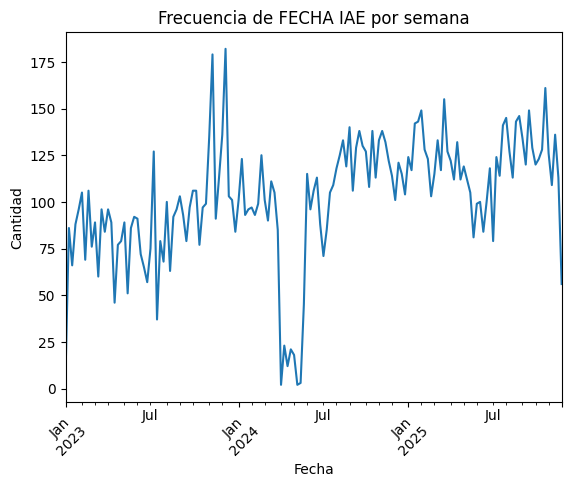

In [609]:
#df_IAE['FECHA IAE'].value_counts()
#conteo = df_IAE['REGISTRO'].dt.date.value_counts().sort_index() # por día
#conteo_semanal = df_IAE.set_index('FECHA IAE').resample('W').size()

#plt.figure()
#conteo_semanal.plot()
#plt.xlabel("Fecha")
#plt.ylabel("Cantidad")
#plt.title("Cantidad de intentos por semana")
#plt.xticks(rotation=45)
#plt.show()

graficar_segun_fecha(df_IAE, 'FECHA IAE', 'W')

In [610]:
mostrar_unicos(df_IAE,'METODO')
mostrar_frecuencias(df_IAE,'METODO')

METODO tiene 282 valores únicos.
['Lesiones autoinfligidas' 'Ingesta de Medicamentos' 'Otros'
 'Arma de fuego' 'Ahorcamiento o asfixia' nan '0'
 'EXPOSICI�N A FACTORES NO ESPECIFICADOS, QUE CAUSAN FRACTURA '
 'AHOGAMIENTO Y SUMERSI�N NO ESPECIFICADOS, CALLES Y CARRETERAS'
 'INHALACI�N DE CONTENIDOS G�STRICOS, INSTITUCI�N RESIDENCIAL'
 'EXPOSICI�N A CORRIENTE EL�CTRICA NO ESPECIFICADA, VIVIENDA'
 'LESI�N AUTOINFLIGIDA INTENCIONALMENTE POR AHORCAMIENTO, ESTRANGULAMIENTO O SOFOCACI�N VIVIENDA'
 'EXPOSICI�N A HUMOS, FUEGOS O LLAMAS NO ESPECIFICADOS, VIVIENDA'
 'OBSTRUCCI�N NO ESPECIFICADA DE LA RESPIRACI�N, LUGAR NO ESPECIFICADO'
 'OBSTRUCCI�N NO ESPECIFICADA DE LA RESPIRACI�N, VIVIENDA'
 'EXPOSICI�N A FACTORES NO ESPECIFICADOS QUE CAUSAN OTRAS LESIONES Y LAS NO ESPECIFICADAS '
 'ENVENENAMIENTO ACCIDENTAL POR, Y EXPOSICI�N AL ALCOHOL, LUGAR NO ESPECIFICADO'
 'EXPOSICI�N A FUEGO NO CONTROLADO EN EDIFICIO U OTRA CONSTRUCCI�N, VIVIENDA'
 'EVENTO NO ESPECIFICADO, DE INTENCI�N NO DETERMINADA, V

In [611]:
df_IAE['METODO'].value_counts().head(20)

METODO
Ingesta de Medicamentos                                                                                                   10916
Otros                                                                                                                      1446
Lesiones autoinfligidas                                                                                                    1333
Ahorcamiento o asfixia                                                                                                     1256
LESI�N AUTOINFLIGIDA INTENCIONALMENTE POR AHORCAMIENTO, ESTRANGULAMIENTO O SOFOCACI�N VIVIENDA                             1115
EXPOSICI�N A FACTORES NO ESPECIFICADOS, QUE CAUSAN FRACTURA                                                                 612
EXPOSICI�N A FACTORES NO ESPECIFICADOS QUE CAUSAN OTRAS LESIONES Y LAS NO ESPECIFICADAS                                     401
LESI�N AUTOINFLIGIDA INTENCIONALMENTE POR DISPARO DE OTRAS ARMAS DE FUEGO, Y LAS NO ESPECIFICADAS

In [612]:
df_IAE = acondicionar_atributo_metodo(df_IAE)

In [613]:
mostrar_frecuencias(df_IAE, 'METODO')

METODO
Ingesta de Medicamentos                                                                           10916
Ahorcamiento o asfixia                                                                             3066
Otros                                                                                              2523
Lesiones autoinfligidas                                                                            1551
Armas de fuego                                                                                      429
                                                                                                  ...  
OTROS EVENTOS ESPECIFICADOS, DE INTENCI�N NO DETERMINADA, INSTITUCI�N RESIDENCIAL                     1
EXPOSICIÓN A OTRAS FUERZAS MEC�NICAS INANIMADAS, Y LAS NO ESPECIFICADAS, LUGAR NO ESPECIFICADO        1
EXPLOSI�N Y ROTURA DE NEUM�TICO, TUBO O MANGUERA DE GOMA PRESURIZADA, CALLES Y CARRETERAS             1
PRIVACI�N DE ALIMENTOS, VIVIENDA                         

In [614]:
#categorias = ['Ingesta de Medicamentos', 'Ahorcamiento o asfixia','Lesiones autoinfligidas', 'Armas de fuego', 'Caída']
#df_IAE['METODO_'] = df_IAE['METODO'].where(df_IAE['METODO'].isin(categorias), 'Otros')
df_IAE = agregar_categoria_metodo(df_IAE)
mostrar_frecuencias(df_IAE, 'METODO_')

METODO_
Ingesta de Medicamentos    10916
Otros                       3725
Ahorcamiento o asfixia      3066
Lesiones autoinfligidas     1551
Armas de fuego               429
Caída                        184
Name: count, dtype: int64


In [615]:
#df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].str.strip() # Elimino espacios antes y después de los string
#palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr('IAE PREVIO','Tratamiento')
#df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].replace(palabras_a_reemplazar,'Tratamiento')
#df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].replace('Sin dato','NO SE INDICA')
#df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].replace('','NO SE INDICA')
#df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].fillna("NO SE INDICA")

mostrar_frecuencias(df_IAE,'IAE PREVIO')
df_IAE = acondicionar_IAE_PREVIO(df_IAE)
mostrar_frecuencias(df_IAE,'IAE PREVIO')
mostrar_unicos(df_IAE,'IAE PREVIO')

IAE PREVIO
SI                                                                                             7800
NO                                                                                             4824
NO SE INDICA                                                                                   2170
Tratamiento en el prestador habitual                                                            121
Sin dato                                                                                         33
NO                                                                                               10
SI                                                                                                8
Tratamiento en clínica privada                                                                    4
                                                                                                  1
Name: count, dtype: int64
IAE PREVIO
SI              7808
NO SE INDICA    7104
NO        

In [616]:
mostrar_valores_nulos(df_IAE,campo_nacimiento)

FECHA NACIMIENTO tiene 4826 valores nulos


In [617]:
#df_IAE['FECHA IAE'] = pd.to_datetime(df_IAE['FECHA IAE'], errors='coerce')
#df_IAE[campo_nacimiento] = pd.to_datetime(df_IAE[campo_nacimiento], errors='coerce')
#df_IAE['EDAD_'] = df_IAE['FECHA IAE'].dt.year - df_IAE[campo_nacimiento].dt.year
df_IAE = calcular_y_agregar_campo_edad(df_IAE, 'FECHA IAE', campo_nacimiento)
mostrar_rango(df_IAE, 'EDAD_')

El rango del atributo EDAD_ es [0.0, 113.0]


In [618]:
if dataset==1:
    coincidencias_edades = np.sum(df_IAE['EDAD_']==df_IAE['EDAD'])
    print(f'Coinciden {coincidencias_edades} de {len(df_IAE['EDAD_'])} edades')

In [619]:
campo_edad = 'EDAD_' if dataset==2 else 'EDAD' 
#edades_IAE = df_IAE[campo_edad].unique()
#print(edades_IAE)
#print(np.nanmin(edades_IAE), np.nanmax(edades_IAE))
#print(np.sum(np.isnan(edades_IAE)))
mostrar_unicos(df_IAE, campo_edad)
mostrar_rango(df_IAE, campo_edad)

EDAD_ tiene 98 valores únicos.
[ 14.  21.  17.  71.  27.  37.  53.  44.  32.  23.  49.  48.  82.  16.
  13.  24.  19.  63.  18.  25.  38.  41.  55.  33.  28.  20.  56.  47.
  15.  45.  35.  26.  62.  31.  58.  30.  61.  66.  29.  42.  52.  36.
  76.  nan  60.  54.  22.  12.  69.  34.   0.  65.  11.  39.  57.  77.
  67.  87.  43.  64.  46.  51.  86.  50.  40.  70.  59.  10.  73.  85.
  80.  79.  78.  72.  74.  84.   7.  68.  94.  89.  91.  81.  90. 103.
  88.  95.  98.  75.  83.   8.   9.  93.  96.  92.   2.   3. 113.   6.]
El rango del atributo EDAD_ es [0.0, 113.0]


In [620]:
df_IAE = discretizar(df_IAE, campo_edad, "GRUPO_EDAD_", 5)

In [621]:
# como esta columna contiene información del resultado (Suicidio o no), me quedan dudas de si es conveniente usarla para predecir. 
# Llama la aención la cantidad de casos en que no se cumple protocolo


#df_IAE[campo_decision] = df_IAE[campo_decision].str.strip() #saco espacios adelante y atras
#df_IAE[campo_decision].value_counts()

In [622]:
df_IAE = acondicionar_campo_DECISION(df_IAE, campo_decision)
mostrar_unicos(df_IAE, campo_decision)
mostrar_frecuencias(df_IAE, campo_decision)
#filas_unicas

DECISION tiene 13 valores únicos.
['NO CUMPLE PROTOCOLO' 'RESUELTO' 'PENDIENTE RESPUESTA' nan 'INTERNADO'
 'SIN COBERTURA ASISTENCIAL' 'SUICIDIO' 'SIN DATOS ASISTENCIALES'
 'RESPUESTA' 'PRIVADO DE LIBERTAD' 'RESUELT0'
 'FECHA ERRONEA DE IAE? UN AÑO ATRASO' 'SEG PARTICULAR']
DECISION
RESUELTO                               5887
NO CUMPLE PROTOCOLO                    2281
PENDIENTE RESPUESTA                    1360
INTERNADO                                68
SIN COBERTURA ASISTENCIAL                59
SUICIDIO                                 45
SIN DATOS ASISTENCIALES                   5
RESPUESTA                                 1
PRIVADO DE LIBERTAD                       1
RESUELT0                                  1
FECHA ERRONEA DE IAE? UN AÑO ATRASO       1
SEG PARTICULAR                            1
Name: count, dtype: int64


In [623]:
# se agrupan las decisiones

#palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'RESUELTO')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'RESUELTO')

#palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'NO CUMPLE')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'NO CUMPLE PROTOCOLO')

#palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'SUICIDIO')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'SUICIDIO')

#palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'INTERNAD')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'INTERNADO')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace('INTERNADO ','INTERNADO')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace('PENDIENTE INTERNADO','INTERNADO')

#palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'PENDIENTE RESPUESTA')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'PENDIENTE RESPUESTA')
#palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'PENDEINTE RESPUESTA')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'PENDIENTE RESPUESTA')

#df_IAE[campo_decision] = df_IAE[campo_decision].replace('SIN RESPUESTA DEFINITIVA','PENDIENTE RESPUESTA')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace('SIN RESPUESTA','PENDIENTE RESPUESTA')


#df_IAE[campo_decision].unique()

In [624]:
# se crea una nueva columna DECISION_ con 6 categorías.
#df_IAE['DECISION_'] = df_IAE[campo_decision].copy()

#categorias = ['RESUELTO', 'NO CUMPLE PROTOCOLO','PENDIENTE RESPUESTA','INTERNADO', 'SUICIDIO']
#df_IAE['DECISION_'] = df_IAE['DECISION_'].where(df_IAE['DECISION_'].isin(categorias), 'OTRA DECISION')

agregar_campo_DECISION(df_IAE, campo_decision, 'DECISION_')
mostrar_unicos(df_IAE,campo_decision)
mostrar_frecuencias(df_IAE,campo_decision)
mostrar_unicos(df_IAE, 'DECISION_')
mostrar_frecuencias(df_IAE, 'DECISION_')

DECISION tiene 13 valores únicos.
['NO CUMPLE PROTOCOLO' 'RESUELTO' 'PENDIENTE RESPUESTA' nan 'INTERNADO'
 'SIN COBERTURA ASISTENCIAL' 'SUICIDIO' 'SIN DATOS ASISTENCIALES'
 'RESPUESTA' 'PRIVADO DE LIBERTAD' 'RESUELT0'
 'FECHA ERRONEA DE IAE? UN AÑO ATRASO' 'SEG PARTICULAR']
DECISION
RESUELTO                               5887
NO CUMPLE PROTOCOLO                    2281
PENDIENTE RESPUESTA                    1360
INTERNADO                                68
SIN COBERTURA ASISTENCIAL                59
SUICIDIO                                 45
SIN DATOS ASISTENCIALES                   5
RESPUESTA                                 1
PRIVADO DE LIBERTAD                       1
RESUELT0                                  1
FECHA ERRONEA DE IAE? UN AÑO ATRASO       1
SEG PARTICULAR                            1
Name: count, dtype: int64
DECISION_ tiene 6 valores únicos.
['NO CUMPLE PROTOCOLO' 'RESUELTO' 'PENDIENTE RESPUESTA' 'OTRA DECISION'
 'INTERNADO' 'SUICIDIO']
DECISION_
OTRA DECISION        

In [625]:
#df_IAE['IAE PREVIO'].value_counts()
mostrar_frecuencias(df_IAE, 'IAE PREVIO')
mostrar_unicos(df_IAE, 'IAE PREVIO')

IAE PREVIO
SI              7808
NO SE INDICA    7104
NO              4834
Tratamiento      125
Name: count, dtype: int64
IAE PREVIO tiene 4 valores únicos.
['NO SE INDICA' 'SI' 'NO' 'Tratamiento']


In [626]:
#df_IAE["DEFUNCION_"] = df_IAE["CEDULA"].isin(df_IAE_CDE["cedula"]).astype(int)
#print(np.sum(df_IAE["DEFUNCION_"])) # 309 intentos asociados a personas fallecidas
                                    # 4756 intentos asociados a personas fallecidas en la segunda entrega!!

df_IAE = agregar_si_intentos_en_CDE(df_IAE, df_IAE_CDE, 'IAE_en_CDE')                                    

Se agrego el campo IAE_en_CDE que vale 1 si la persona falleció (no necesariamente suicidio)
4756 de los 19871 intentos están asociados a personas fallecidas


In [627]:
df_IAE_CDE.head()

,cedula,fecha_defuncion,causa_basica_muerte_valor,causa_basica_muerte_descripcion,lugar_ocurrencia,lugar_ocurrencia_detalle,departamento_ocurrencia,edad_fallecimiento_calculada,edad_fallecimiento_digitada,estado_civil,etnia,mayor_nivel_educacion,institucion_fallecio,es_motivo_externo,motivo_externo,motivo_externo_desc,CAT_SUI_,CAT_MCEXSUI_,grupo edades_
0,0004278339f5f72aa648112ee2ea5968932e11d34147aa...,2025-08-06,X707,LESIÓN AUTOINFLIGIDA INTENCIONALMENTE POR AHOR...,OTRO,JURISDICCION DE SECCIONAL 12,AR,29.0,29.0,SOLTERO,BLANCA,SE DESCONOCE,NaN,S,SUICIDIO,ES ENCONTRADO EL CADÁVER COLGANDO DE UN ÁRBOL ...,1,0,27.5
1,0019b23cfe93768b7cdde4b1368e2b4b9591e64d5de3c1...,2024-04-21,Y260,"EXPOSICIÓN AL HUMO, FUEGO Y LLAMAS, DE INTENCI...",DOMICILIO,NaN,RV,NaN,64.0,SOLTERO,BLANCA,SE DESCONOCE,NaN,D,NaN,NaN,0,0,NaN
2,001da1f6d77a1a72835bba4c2b9d4ccdf297d90e00ada4...,2023-05-22,X849,LESIÓN AUTOINFLIGIDA INTENCIONALMENTE POR MEDI...,CENTRO ASISTENCIAL,NaN,MO,53.0,53.0,VIUDO,BLANCA,PRIMARIA COMPLETA,102.0,N,NaN,NaN,1,0,52.5
3,00238e5fe1190d87676fb70c58e36805b76e0e57e125b5...,2023-07-17,X599,EXPOSICIÓN A FACTORES NO ESPECIFICADOS QUE CAU...,CENTRO ASISTENCIAL,NaN,CL,85.0,85.0,CASADO,BLANCA,SE DESCONOCE,117.0,N,NaN,NaN,0,1,87.5
4,0023c61ba8506e99778380cfecdded0cadbac263fe9cdf...,2023-03-20,Y260,"EXPOSICIÓN AL HUMO, FUEGO Y LLAMAS, DE INTENCI...",OTRO,OTRO DOMICILIO,MO,26.0,26.0,SOLTERO,BLANCA,SE DESCONOCE,NaN,S,SE DESCONOCE,"Incendio en vivienda, se desconoce origen del ...",0,0,27.5


In [628]:
#df_IAE["FECHA_DEFUNCION"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["fecha_defuncion"])
#df_IAE["CAUSA_MUERTE"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["causa_basica_muerte_valor"])
#df_IAE["DPTO_MUERTE"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["departamento_ocurrencia"])
#df_IAE["EDAD_MUERTE"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["edad_fallecimiento_digitada"])
#df_IAE["GRUPO_EDAD_MUERTE"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["grupo edades"])
#df_IAE["MOTIVO_EXTERNO_"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["motivo_externo"])
#df_IAE["MOTIVO_EXT_SUI_"] = df_IAE["MOTIVO_EXTERNO_"]=='SUICIDIO'
#df_IAE["ES_MOTIVO_EXTERNO_"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["es_motivo_externo"])
#df_IAE["CAT_SUI_"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["CAT_SUI_"])
#df_IAE["CAT_MCEXSUI_"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["CAT_MCEXSUI_"])

df_IAE = agregar_datos_CDE_en_IAE(df_IAE, df_IAE_CDE, dataset)


In [629]:
df_IAE.keys()

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       'METODO', 'IAE PREVIO', 'FECHA IAE', 'FECHA SEGUIMIENTO',
       'FECHA LLAMADA PRESTADOR', 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO',
       'FECHA DE CONSULTA', 'CONCURRIO', 'SE LLAMO A USUARIO Y/O REFERENTE',
       'AGENDO NUEVA CONSULTA', 'FECHA DE NUEVA CONSULTA', 'INTERNACION',
       'FECHA ALTA', 'FECHA LLAMADA PRESTADOR.1', 'MSP', 'OBSERVACIONES',
       'UNNAMED: 26', 'FECHA DE LLAMADA AL PRESTADOR', 'MOTIVO',
       'tiene_registro_', 'es_IAE_', 'Tipo_prestador_IAE_',
       'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_', 'METODO_', 'EDAD_',
       'GRUPO_EDAD_', 'DECISION_', 'IAE_en_CDE', 'FECHA_DEFUNCION',
       'CAUSA_MUERTE', 'DPTO_MUERTE', 'EDAD_MUERTE', 'GRUPO_EDAD_MUERTE',
       'CAT_SUI_', 'CAT_MCEXSUI_', 'DIAS_IAE_MUERTE_', 'CDE_lugar_ocurrencia',
       'CDE_departamento_ocurrencia', 'CDE_estado_civil', 'CDE_etn

In [630]:
if dataset==2:
    mostrar_frecuencias(df_IAE, "MOTIVO_EXTERNO_")
    mostrar_frecuencias(df_IAE, "MOTIVO_EXT_SUI_")
    df_IAE.loc[df_IAE['PRESTADOR'].isnull(), 'IAE_en_CDE'].value_counts()
    df_IAE.loc[df_IAE['PRESTADOR_PRIVADO_'].isnull(), 'ES_MOTIVO_EXTERNO_'].value_counts()

MOTIVO_EXTERNO_
SUICIDIO        2171
ACCIDENTE        506
SE DESCONOCE     207
OTRO              42
HOMICIDIO          3
Name: count, dtype: int64
MOTIVO_EXT_SUI_
False    17700
True      2171
Name: count, dtype: int64


In [631]:
#df_IAE['IAE PREVIO'].value_counts()
mostrar_frecuencias(df_IAE, 'IAE PREVIO')

IAE PREVIO
SI              7808
NO SE INDICA    7104
NO              4834
Tratamiento      125
Name: count, dtype: int64


In [632]:
df_IAE.keys()

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       'METODO', 'IAE PREVIO', 'FECHA IAE', 'FECHA SEGUIMIENTO',
       'FECHA LLAMADA PRESTADOR', 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO',
       'FECHA DE CONSULTA', 'CONCURRIO', 'SE LLAMO A USUARIO Y/O REFERENTE',
       'AGENDO NUEVA CONSULTA', 'FECHA DE NUEVA CONSULTA', 'INTERNACION',
       'FECHA ALTA', 'FECHA LLAMADA PRESTADOR.1', 'MSP', 'OBSERVACIONES',
       'UNNAMED: 26', 'FECHA DE LLAMADA AL PRESTADOR', 'MOTIVO',
       'tiene_registro_', 'es_IAE_', 'Tipo_prestador_IAE_',
       'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_', 'METODO_', 'EDAD_',
       'GRUPO_EDAD_', 'DECISION_', 'IAE_en_CDE', 'FECHA_DEFUNCION',
       'CAUSA_MUERTE', 'DPTO_MUERTE', 'EDAD_MUERTE', 'GRUPO_EDAD_MUERTE',
       'CAT_SUI_', 'CAT_MCEXSUI_', 'DIAS_IAE_MUERTE_', 'CDE_lugar_ocurrencia',
       'CDE_departamento_ocurrencia', 'CDE_estado_civil', 'CDE_etn

In [633]:
if dataset==2:
    print(df_IAE[df_IAE['IAE PREVIO']=='NO SE INDICA']['ES_MOTIVO_EXTERNO_'].value_counts())
    print(df_IAE["CAT_SUI_"].sum(), df_IAE["CAT_MCEXSUI_"].sum(), df_IAE["IAE_en_CDE"].sum(), df_IAE["MOTIVO_EXTERNO_"].value_counts().sum())
    mostrar_valores_nulos(df_IAE, "CAT_SUI_")

ES_MOTIVO_EXTERNO_
S    2766
N    1529
D     103
Name: count, dtype: int64
2218.0 2073.0 4756 2929
CAT_SUI_ tiene 15115 valores nulos


In [634]:
if dataset==2:
    df_IAE = corregir_fechas_enteras_prestadores(df_IAE)
    df_IAE = acondicionar_campos_prestadores(df_IAE)
    df_IAE = acondicionar_CONCURRIO(df_IAE, 'CONCURRIO_', 'CONCURRIO_binaria')
    df_IAE = acondicionar_campo_agendo_consulta_en_7dias(df_IAE,'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO_')
    mostrar_frecuencias(df_IAE,'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO_')

En el campo FECHA SEGUIMIENTO se corrigieron 0 fechas enteras
En el campo FECHA LLAMADA PRESTADOR se corrigieron 0 fechas enteras
En el campo AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO se corrigieron 0 fechas enteras
En el campo FECHA DE CONSULTA se corrigieron 4900 fechas enteras
En el campo CONCURRIO se corrigieron 5516 fechas enteras
En el campo SE LLAMO A USUARIO Y/O REFERENTE se corrigieron 1 fechas enteras
En el campo AGENDO NUEVA CONSULTA se corrigieron 2 fechas enteras
En el campo FECHA DE NUEVA CONSULTA se corrigieron 312 fechas enteras
En el campo INTERNACION se corrigieron 617 fechas enteras
En el campo FECHA ALTA se corrigieron 2826 fechas enteras
En el campo FECHA LLAMADA PRESTADOR.1 se corrigieron 1149 fechas enteras
En el campo MSP se corrigieron 5820 fechas enteras
En el campo OBSERVACIONES se corrigieron 1 fechas enteras
En el campo UNNAMED: 26 se corrigieron 0 fechas enteras
En el campo FECHA DE LLAMADA AL PRESTADOR se corrigieron 44 fechas enteras
En el campo MOTIVO s

/home/carbajal/Documents/SaludMental/codigo_solucionadores/utils/utils.py:125: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<DatetimeArray>
['2023-04-05 00:00:00', '2023-07-03 00:00:00', '2023-07-14 00:00:00',
 '2023-12-27 00:00:00', '2024-12-26 00:00:00', '2025-08-21 00:00:00',
 '2025-08-13 00:00:00', '2023-02-22 00:00:00', '2023-05-05 00:00:00',
 '2023-03-10 00:00:00',
 ...
 '2023-05-29 00:00:00', '2023-06-07 00:00:00', '2023-03-09 00:00:00',
 '2023-02-16 00:00:00', '2023-04-11 00:00:00', '2023-05-19 00:00:00',
 '2023-04-10 00:00:00', '2023-04-12 00:00:00', '2023-06-09 00:00:00',
 '2023-08-10 00:00:00']
Length: 312, dtype: datetime64[ns]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  resultado[mask] = pd.to_datetime(
/home/carbajal/Documents/SaludMental/codigo_solucionadores/utils/utils.py:125: FutureWarning: Setting an item of incompatible dtype is depreca

AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO_
SI                            9130
NO                            3583
PENDIENTE RESPUESTA           1966
DESCARTADA_POR_RASTREADOR      275
INTERNADO                      185
NO CUMPLE PROTOCOLO             64
SUICIDIO                        56
SIN COBERTURA ASISTENCIAL       52
SEGUIMIENTO PARTICULAR          17
SIN DATO ASISTENCIAL             5
PRIVADO DE LIBERTAD              4
SIN REGISTRO                     2
                                 1
IAE CONSECUTIVO?                 1
DOBLE IAE ? 10/10 Y 11/10?       1
DOBLE IAE ? 29/09 Y 30/09?       1
Name: count, dtype: int64


/home/carbajal/Documents/SaludMental/codigo_solucionadores/utils/IAE.py:269: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  es_fecha = pd.to_datetime(df_IAE[nombre_campo], errors="coerce").notna()


In [635]:
if dataset==2:
    indices = df_IAE['FECHA LLAMADA PRESTADOR.1_'].isnull() * df_IAE['FECHA DE LLAMADA AL PRESTADOR_'].isnull()
    df_IAE.loc[~indices,['FECHA LLAMADA PRESTADOR.1_','FECHA DE LLAMADA AL PRESTADOR_', 'MSP_']].tail(30)

In [636]:
if dataset==2:
    mostrar_unicos(df_IAE,'FECHA LLAMADA PRESTADOR.1_')
    mostrar_unicos(df_IAE,'FECHA DE LLAMADA AL PRESTADOR_')
    mostrar_unicos(df_IAE,'MSP_')


FECHA LLAMADA PRESTADOR.1_ tiene 253 valores únicos.
[nan '2023-07-26 00:00:00' '2023-08-27 00:00:00' '2023-09-14 00:00:00'
 '17/09/2023 FUGA' '2023-10-03 00:00:00' '2023-10-06 00:00:00'
 '2023-10-11 00:00:00' '2023-10-20 00:00:00' '2023-10-17 00:00:00'
 '2023-10-19 00:00:00' '2023-10-27 00:00:00' '2023-10-13 00:00:00'
 '2023-10-14 00:00:00' '2023-10-21 00:00:00' '2023-10-22 00:00:00'
 '2023-11-14 00:00:00' '2023-10-02 00:00:00' '2023-10-16 00:00:00'
 '2023-10-23 00:00:00' '2023-10-31 00:00:00' '2023-11-07 00:00:00'
 '2023-10-24 00:00:00' '2023-10-25 00:00:00' '2023-10-26 00:00:00'
 '2023-11-03 00:00:00' '2023-11-29 00:00:00' '2023-11-01 00:00:00'
 '2023-11-06 00:00:00' '2023-11-20 00:00:00' '2023-10-30 00:00:00'
 '2023-12-12 00:00:00' '2023-11-10 00:00:00' '2023-10-28 00:00:00' 'SD'
 'SE FUGA' '2023-10-29 00:00:00' '2023-11-13 00:00:00' 'FUGA 27/10'
 'FUGA 28/10' '2023-11-02 00:00:00' 'SIGUE' 'PEND' '2023-11-04 00:00:00'
 '2023-11-17 00:00:00' '2023-11-11 00:00:00' '2023-11-09 00:00:0

In [637]:
if dataset==2:
    cambios = ~(df_IAE['FECHA DE CONSULTA'].eq(df_IAE['FECHA DE CONSULTA_']) |
                (df_IAE['FECHA DE CONSULTA'].isna() & df_IAE['FECHA DE CONSULTA_'].isna()))
    np.sum(cambios)

In [638]:
df_IAE.keys()

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       'METODO', 'IAE PREVIO', 'FECHA IAE', 'FECHA SEGUIMIENTO',
       'FECHA LLAMADA PRESTADOR', 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO',
       'FECHA DE CONSULTA', 'CONCURRIO', 'SE LLAMO A USUARIO Y/O REFERENTE',
       'AGENDO NUEVA CONSULTA', 'FECHA DE NUEVA CONSULTA', 'INTERNACION',
       'FECHA ALTA', 'FECHA LLAMADA PRESTADOR.1', 'MSP', 'OBSERVACIONES',
       'UNNAMED: 26', 'FECHA DE LLAMADA AL PRESTADOR', 'MOTIVO',
       'tiene_registro_', 'es_IAE_', 'Tipo_prestador_IAE_',
       'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_', 'METODO_', 'EDAD_',
       'GRUPO_EDAD_', 'DECISION_', 'IAE_en_CDE', 'FECHA_DEFUNCION',
       'CAUSA_MUERTE', 'DPTO_MUERTE', 'EDAD_MUERTE', 'GRUPO_EDAD_MUERTE',
       'CAT_SUI_', 'CAT_MCEXSUI_', 'DIAS_IAE_MUERTE_', 'CDE_lugar_ocurrencia',
       'CDE_departamento_ocurrencia', 'CDE_estado_civil', 'CDE_etn

In [639]:
if dataset==2:
    print(df_IAE['CONCURRIO'].unique().tolist())
    df_IAE['CONCURRIO_'] = convertir_enteros_a_fecha(df_IAE['CONCURRIO'])
    print(df_IAE['CONCURRIO_'].unique().tolist())

[nan, 'SI ', 'NO ', 'SI', 'NO', 'si', 'no', '45482', '45712', 'TELEFONICA', '45686', '45400', '45399', '45481', '45454', '45442', '45440', '45441', '30/0', '45448', '45439', '45446', '45447', '45443', '45449', '45456', '45444', '45694', '45469', '45455', '45474', '45467', '45450', '45468', '45451', '45453', '45461', '45457', '45460', '45471', '45452', '45550', '45477', '45463', '45506', '45693', '45462', '45553', '45437', '45476', '45490', '45458', '45464', '45486', '45470', '45483', '45500', '45465', '45478', '45484', '45475', '45466', '45533', '18/06/20254', '45485', '45502', '45540', '45516', '45489', '45523', '45488', '45492', '45499', '45503', '45495', '45497', '45504', '45496', '45519', '45509', '45505', '45498', '45527', '45653', '45511', '45512', '45525', '45541', '25/07/204 ', '45518', '45513', '45535', '45510', '45517', '45531', '45537', '45526', '45524', '45514', '45545', '45520', '45521', '45589', '45705', '09/08 PSIC', '45532', '45530', '45539', '45534', '45548', '45515', 

In [640]:
if dataset==2:
    print(df_IAE['AGENDO NUEVA CONSULTA'].unique().tolist())
    df_IAE['AGENDO NUEVA CONSULTA_'] = convertir_enteros_a_fecha(df_IAE['AGENDO NUEVA CONSULTA'])
    print(df_IAE['AGENDO NUEVA CONSULTA_'].unique().tolist())

['NO', 'SI ', nan, 'si', 'SI', 'NO ', 'no', 'pend ', '?', 'PEND', '45863', 'BRASIL', 'pend', 'pen', '45079', 'PEND ', 'PENDIENTE']
['NO', 'SI ', nan, 'si', 'SI', 'NO ', 'no', 'pend ', '?', 'PEND', Timestamp('2025-07-25 00:00:00'), 'BRASIL', 'pend', 'pen', Timestamp('2023-06-02 00:00:00'), 'PEND ', 'PENDIENTE']


In [641]:
df_IAE.columns

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       'METODO', 'IAE PREVIO', 'FECHA IAE', 'FECHA SEGUIMIENTO',
       'FECHA LLAMADA PRESTADOR', 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO',
       'FECHA DE CONSULTA', 'CONCURRIO', 'SE LLAMO A USUARIO Y/O REFERENTE',
       'AGENDO NUEVA CONSULTA', 'FECHA DE NUEVA CONSULTA', 'INTERNACION',
       'FECHA ALTA', 'FECHA LLAMADA PRESTADOR.1', 'MSP', 'OBSERVACIONES',
       'UNNAMED: 26', 'FECHA DE LLAMADA AL PRESTADOR', 'MOTIVO',
       'tiene_registro_', 'es_IAE_', 'Tipo_prestador_IAE_',
       'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_', 'METODO_', 'EDAD_',
       'GRUPO_EDAD_', 'DECISION_', 'IAE_en_CDE', 'FECHA_DEFUNCION',
       'CAUSA_MUERTE', 'DPTO_MUERTE', 'EDAD_MUERTE', 'GRUPO_EDAD_MUERTE',
       'CAT_SUI_', 'CAT_MCEXSUI_', 'DIAS_IAE_MUERTE_', 'CDE_lugar_ocurrencia',
       'CDE_departamento_ocurrencia', 'CDE_estado_civil', 'CDE_etn

In [642]:
if dataset==1:
    graficar_segun_fecha(df_IAE_CDE,'fecha_defuncion','W')

In [643]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19871 entries, 0 to 19883
Data columns (total 74 columns):
 #   Column                                      Non-Null Count  Dtype          
---  ------                                      --------------  -----          
 0   ID                                          15584 non-null  float64        
 1   CEDULA                                      19871 non-null  object         
 2   NOMBRE                                      0 non-null      float64        
 3   APELLIDO                                    0 non-null      float64        
 4   PERSONA                                     19340 non-null  object         
 5   FECHA NACIMIENTO                            15044 non-null  datetime64[ns] 
 6   DECISION                                    9710 non-null   object         
 7   PRESTADOR                                   15585 non-null  object         
 8   ESTABLECIMIENTO REGISTRO                    12496 non-null  object         
 9   

In [644]:
# días que transcurren desde el IAE hasta la muerte. Si la persona no murió se pone nan
#df_IAE['DIAS_IAE_MUERTE_'] = (df_IAE["FECHA_DEFUNCION"] - df_IAE["FECHA IAE"])
mostrar_frecuencias(df_IAE,'DIAS_IAE_MUERTE_')

DIAS_IAE_MUERTE_
0 days      15
2 days      12
4 days      10
9 days       7
1 days       7
            ..
901 days     1
214 days     1
685 days     1
587 days     1
106 days     1
Name: count, Length: 316, dtype: int64


In [645]:
df_IAE.loc[df_IAE['DIAS_IAE_MUERTE_'].dt.days<0, ['FECHA IAE', 'FECHA_DEFUNCION']]

,FECHA IAE,FECHA_DEFUNCION
12310,2023-05-03,2023-03-09
12688,2023-06-01,2023-02-12
12750,2023-09-04,2023-08-25
12848,2023-08-03,2023-07-28
13019,2023-11-05,2023-05-14
13149,2023-10-06,2023-09-05
13237,2023-11-02,2023-05-13
13240,2023-12-02,2023-06-04
13249,2023-12-03,2023-04-04
13325,2023-11-08,2023-09-28


In [646]:
#df_IAE['DIAS_IAE_MUERTE_'].unique()  # días transcurridos desde un IAE hasta muerte
mostrar_unicos(df_IAE,'DIAS_IAE_MUERTE_')

DIAS_IAE_MUERTE_ tiene 317 valores únicos.
<TimedeltaArray>
[       NaT, '227 days', '834 days', '405 days',  '21 days',  '26 days',
 '353 days',   '1 days',   '2 days', '543 days',
 ...
 '729 days', '617 days', '737 days', '614 days', '429 days', '901 days',
 '214 days', '685 days', '587 days', '106 days']
Length: 317, dtype: timedelta64[ns]


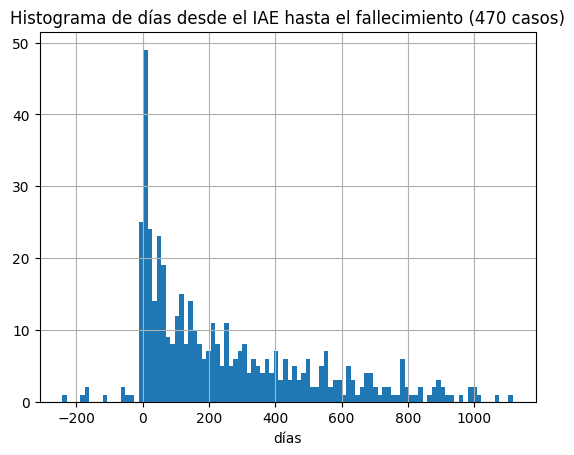

In [647]:
plt.figure()
df_IAE['DIAS_IAE_MUERTE_'].dt.days.hist(bins=100)
n_casos = df_IAE['DIAS_IAE_MUERTE_'].value_counts().sum()
plt.title(f'Histograma de días desde el IAE hasta el fallecimiento ({n_casos} casos)')
plt.xlabel('días')
plt.show()

In [648]:
df_IAE.keys()

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       'METODO', 'IAE PREVIO', 'FECHA IAE', 'FECHA SEGUIMIENTO',
       'FECHA LLAMADA PRESTADOR', 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO',
       'FECHA DE CONSULTA', 'CONCURRIO', 'SE LLAMO A USUARIO Y/O REFERENTE',
       'AGENDO NUEVA CONSULTA', 'FECHA DE NUEVA CONSULTA', 'INTERNACION',
       'FECHA ALTA', 'FECHA LLAMADA PRESTADOR.1', 'MSP', 'OBSERVACIONES',
       'UNNAMED: 26', 'FECHA DE LLAMADA AL PRESTADOR', 'MOTIVO',
       'tiene_registro_', 'es_IAE_', 'Tipo_prestador_IAE_',
       'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_', 'METODO_', 'EDAD_',
       'GRUPO_EDAD_', 'DECISION_', 'IAE_en_CDE', 'FECHA_DEFUNCION',
       'CAUSA_MUERTE', 'DPTO_MUERTE', 'EDAD_MUERTE', 'GRUPO_EDAD_MUERTE',
       'CAT_SUI_', 'CAT_MCEXSUI_', 'DIAS_IAE_MUERTE_', 'CDE_lugar_ocurrencia',
       'CDE_departamento_ocurrencia', 'CDE_estado_civil', 'CDE_etn

In [649]:
#for atributo in df_IAE.keys():
#    mostrar_valores_nulos(df_IAE,atributo)
#    mostrar_unicos(df_IAE,atributo)
#    mostrar_frecuencias(df_IAE,atributo)

In [650]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19871 entries, 0 to 19883
Data columns (total 74 columns):
 #   Column                                      Non-Null Count  Dtype          
---  ------                                      --------------  -----          
 0   ID                                          15584 non-null  float64        
 1   CEDULA                                      19871 non-null  object         
 2   NOMBRE                                      0 non-null      float64        
 3   APELLIDO                                    0 non-null      float64        
 4   PERSONA                                     19340 non-null  object         
 5   FECHA NACIMIENTO                            15044 non-null  datetime64[ns] 
 6   DECISION                                    9710 non-null   object         
 7   PRESTADOR                                   15585 non-null  object         
 8   ESTABLECIMIENTO REGISTRO                    12496 non-null  object         
 9   

In [651]:
if dataset==2:
    df_IAE.loc[indices_malos, 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO'].value_counts()

In [652]:
bad = df_IAE[df_IAE.isna().sum(axis=1) > 24]
bad.dropna(axis=1, how='all')

,ID,CEDULA,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,...,FECHA ALTA_,FECHA LLAMADA PRESTADOR.1_,MSP_,OBSERVACIONES_,UNNAMED: 26_,FECHA DE LLAMADA AL PRESTADOR_,MOTIVO_,CONCURRIO_binaria,NO_CONCURRIO_CONSULTA_,DESCARTADA_POR_RASTREADOR
0,895.0,75b770ddbd1a43188f867d9ef8df0980412cb32b12374c...,Femenino,2009-09-01,NO CUMPLE PROTOCOLO,UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA,NaN,2023-01-24,Lesiones autoinfligidas,NO SE INDICA,...,NaN,NaN,VALENTINA ACOSTA,NaN,NaN,NaN,NaN,NaN,False,False
1,1507.0,f5138e15e53b4df18a439fd908b90d42c88c708280daac...,Femenino,2002-09-01,RESUELTO,CAMEC,NaN,2023-03-14,Ingesta de Medicamentos,SI,...,NaN,NaN,LIC ROMANO,,NaN,NaN,NaN,NaN,False,False
2,2677.0,919938e34174fd08e1fd49e678fc985160d058c6ea74d4...,Masculino,2006-05-01,RESUELTO,MEDICA URUGUAYA MUCAM,NaN,2023-06-08,Otros,SI,...,NaN,NaN,LIC ROMANO,DRA FERNANDEZ,NaN,NaN,NaN,SI,False,False
3,2804.0,6fb148c1f5d374e972746773f234955641ffee740f61f2...,Femenino,1952-07-01,PENDIENTE RESPUESTA,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,SANATORIO JUAN PABLO II,2023-06-19,Ingesta de Medicamentos,NO,...,NaN,NaN,VALENTINA ACOSTA,ENVIO EMAIL AL CIRCULO SOLICITANDO INFORMACION.,NaN,NaN,NaN,NaN,False,False
4,2805.0,182eafb797ccb4f8a55b932370740d5ab89093978223ae...,Femenino,1996-07-01,PENDIENTE RESPUESTA,CUDAM,CENTRAL,2023-06-19,Ingesta de Medicamentos,SI,...,NaN,NaN,VALENTINA ACOSTA,ME COMUNICO CON SUPERVISORA DE ARCHIVOS EN BUS...,NaN,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19879,NaN,ca22ff093b04f0c7b98744c37337fabce487dcefeaebf3...,Masculino,NaT,NaN,NaN,NaN,2025-01-28,Otros,NO SE INDICA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
19880,NaN,c8426aa7f35f46523c1aded3048e5ca01179c5faf5131c...,Masculino,NaT,NaN,NaN,NaN,2025-02-18,Fuego,NO SE INDICA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
19881,NaN,169d68340bd6eab354ec7ce8ea1d7f6dad739167bb3bf4...,Masculino,NaT,NaN,NaN,NaN,2025-09-03,Fuego,NO SE INDICA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
19882,NaN,fb411d4bf124deb8bffd3b6c1265a7ca09fab1dfc92af1...,Femenino,NaT,NaN,NaN,NaN,2025-10-20,Fuego,NO SE INDICA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False


# Análisis IAE CNV

In [653]:
df_IAE_CNV.shape

(5359, 27)

In [654]:
df_IAE_CNV.keys()

Index(['cedula', 'anio_mes_nacimiento_hijo', 'nro_rese', 'estado_civil',
       'pais_nac', 'pais_residencia', 'mayor_nivel_estudio', 'sexo', 'peso',
       'semanas_gestacion', 'orden', 'certdatospartocodocurrencia', 'apgar1',
       'apgar2', 'tipo_gesta', 'numero_embarazo_anteriores',
       'semana_embarazo_primer_consulta', 'total_consultas', 'mes_parto',
       'lugar_parto', 'lugar_depto', 'tipo_certificador', 'tipo_parto',
       'tipo_cesarea', 'forceps', 'vaccum', 'otra_maniobra'],
      dtype='object')

In [655]:
df_IAE_CNV.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5359 entries, 0 to 5358
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   cedula                           5359 non-null   object        
 1   anio_mes_nacimiento_hijo         5359 non-null   datetime64[ns]
 2   nro_rese                         5359 non-null   object        
 3   estado_civil                     5359 non-null   object        
 4   pais_nac                         5359 non-null   object        
 5   pais_residencia                  5359 non-null   object        
 6   mayor_nivel_estudio              5359 non-null   object        
 7   sexo                             5359 non-null   object        
 8   peso                             5359 non-null   int64         
 9   semanas_gestacion                5359 non-null   int64         
 10  orden                            5359 non-null   int64      

In [656]:
#df_IAE_CNV=df_IAE_CNV.dropna(thresh=2) 
a = conservar_filas_con_n_no_nulos(df_IAE_CNV, 2)

La base tenía 5359 filas. Luego de eliminar las filas con al menos 2 campos nulos quedaron 5359 filas


In [657]:
df_IAE_CNV.shape

(5359, 27)

In [658]:
# Hay 41 duplicados
#df_IAE_CNV.drop_duplicates(inplace=True)
df_IAE_CNV = eliminar_duplicados(df_IAE_CNV)
df_IAE_CNV.shape

Se eliminaron 0 filas duplicadas en la base. Ahora la base tiene 5359 filas.


(5359, 27)

In [659]:
df_IAE_CNV_agrupada = df_IAE_CNV.groupby('cedula')

In [660]:
np.sum(df_IAE_CNV['cedula'].isnull())

np.int64(0)

In [661]:
grupo = df_IAE_CNV_agrupada.get_group('62470455efa50416bcc349b1e52d31b22d00b24af3307c5bf4d417d0dcb90085')
grupo

,cedula,anio_mes_nacimiento_hijo,nro_rese,estado_civil,pais_nac,pais_residencia,mayor_nivel_estudio,sexo,peso,semanas_gestacion,...,total_consultas,mes_parto,lugar_parto,lugar_depto,tipo_certificador,tipo_parto,tipo_cesarea,forceps,vaccum,otra_maniobra
2749,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2017-10-01,37b4a66381ebbbc409a32c72e4b606ca0d949c581787b7...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,M,2900,40,...,14.0,10.0,1.0,MONTEVIDEO,MEDICO,CESAREA,ANTEPARTO,0.0,0.0,0.0
2750,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2008-04-01,e7d4cfe19c14c154992dc5bdf4b819904f0e90568b9c64...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,M,2420,37,...,9.0,4.0,1.0,MONTEVIDEO,MEDICO,VAGINAL,INTRAPARTO,0.0,0.0,0.0
2751,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2013-05-01,2dc74ac2cfb750ed27ca6c24ece46f833e22d0d5fd056c...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,M,3110,41,...,5.0,5.0,1.0,MONTEVIDEO,MEDICO,CESAREA,ANTEPARTO,0.0,0.0,0.0
2752,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2020-11-01,3e1f01b53df2685f0df404be47d6abf82be99d708dcc5e...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,M,2180,38,...,12.0,11.0,1.0,MONTEVIDEO,MEDICO,CESAREA,ANTEPARTO,0.0,0.0,0.0
2753,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2011-09-01,afc5217fc784b883f588519206e6fffaf969f82a63b082...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,F,3120,38,...,9.0,9.0,1.0,MONTEVIDEO,MEDICO,VAGINAL,,0.0,0.0,0.0
2754,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2015-09-01,5172857a40eb4189e4e2517654882b048556964096f97b...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,M,2420,37,...,6.0,9.0,1.0,MONTEVIDEO,MEDICO,CESAREA,ANTEPARTO,0.0,0.0,0.0


In [662]:
fecha_IAE = df_IAE[df_IAE['CEDULA']=='62470455efa50416bcc349b1e52d31b22d00b24af3307c5bf4d417d0dcb90085']['FECHA IAE']
fecha_IAE

4064   2024-09-21
Name: FECHA IAE, dtype: datetime64[ns]

In [663]:
grupo['anio_mes_nacimiento_hijo'].values < fecha_IAE.values

array([ True,  True,  True,  True,  True,  True])

In [664]:
edad_hijo_mayor = (fecha_IAE - grupo['anio_mes_nacimiento_hijo'].max())
edad_hijo_mayor.dt.days/365.25

4064    3.887748
Name: FECHA IAE, dtype: float64

In [665]:
df_IAE = esta_persona_en_CNV(df_IAE_CNV, df_IAE)

if dataset==2:
    df_IAE = esta_nro_rese_en_IAE(df_IAE_CNV, df_IAE)

In [666]:
df_IAE_CNV.keys()

Index(['cedula', 'anio_mes_nacimiento_hijo', 'nro_rese', 'estado_civil',
       'pais_nac', 'pais_residencia', 'mayor_nivel_estudio', 'sexo', 'peso',
       'semanas_gestacion', 'orden', 'certdatospartocodocurrencia', 'apgar1',
       'apgar2', 'tipo_gesta', 'numero_embarazo_anteriores',
       'semana_embarazo_primer_consulta', 'total_consultas', 'mes_parto',
       'lugar_parto', 'lugar_depto', 'tipo_certificador', 'tipo_parto',
       'tipo_cesarea', 'forceps', 'vaccum', 'otra_maniobra'],
      dtype='object')

In [667]:
#df_IAE[["cantidad_hijos", "edad_hijo_mayor", "edad_hijo_menor"]] = df_IAE.apply( lambda row: agregar_datos_hijos_cuando_intento(row, df_IAE, df_IAE_CNV_agrupada), axis=1)
df_IAE = df_IAE.apply( lambda row: agregar_datos_hijos_cuando_intento(row, df_IAE_CNV_agrupada), axis=1)

In [ ]:
if dataset==2:
    df_IAE = df_IAE.apply( lambda row: agregar_datos_CNV_cuando_intento(row, df_IAE_CNV_agrupada), axis=1)

In [ ]:
df_IAE.keys()[10:]

Index(['DECISIÓN', 'tiene_registro_', 'es_IAE_', 'Tipo_prestador_IAE_',
       'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_', 'METODO_', 'EDAD_',
       'GRUPO_EDAD_', 'DECISION_', 'IAE_en_CDE', 'FECHA_DEFUNCION',
       'CAUSA_MUERTE', 'DPTO_MUERTE', 'EDAD_MUERTE', 'GRUPO_EDAD_MUERTE',
       'CAT_SUI_', 'CAT_MCEXSUI_', 'DIAS_IAE_MUERTE_', 'CNV_',
       'CNV_cant_hijos_cuando_IAE', 'CNV_edad_hijo_mayor_cuando_IAE',
       'CNV_edad_hijo_menor_cuando_IAE'],
      dtype='object')

In [ ]:
mostrar_valores_nulos(df_IAE,'CNV_edad_hijo_mayor_cuando_IAE')
mostrar_unicos(df_IAE,'CNV_edad_hijo_mayor_cuando_IAE')
mostrar_frecuencias(df_IAE,'CNV_edad_hijo_mayor_cuando_IAE')

CNV_edad_hijo_mayor_cuando_IAE tiene 8111 valores nulos
CNV_edad_hijo_mayor_cuando_IAE tiene 1848 valores únicos.
[        nan  9.64544832  4.62970568 ...  4.65708419  7.37850787
 13.87816564]
CNV_edad_hijo_mayor_cuando_IAE
10.579055    4
10.918549    4
12.147844    4
10.524298    4
11.321013    4
            ..
12.117728    1
12.761123    1
4.506502     1
8.810404     1
8.769336     1
Name: count, Length: 1847, dtype: int64


In [ ]:
if dataset==2:
    mostrar_frecuencias(df_IAE,'CNV_ultimo_cuando_IAE_mayor_nivel_estudio')

In [ ]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10417 entries, 0 to 10426
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype          
---  ------                          --------------  -----          
 0   CEDULA                          10417 non-null  object         
 1   PERSONA                         10417 non-null  object         
 2   NACIMIENTO                      10416 non-null  datetime64[ns] 
 3   PRESTADOR RECODIFICADO          10414 non-null  object         
 4   ESTABLECIMIENTO REGISTRO        7501 non-null   object         
 5   REGISTRO                        10417 non-null  datetime64[ns] 
 6   METODO                          10417 non-null  object         
 7   IAE PREVIO                      10417 non-null  object         
 8   FECHA IAE                       10417 non-null  datetime64[ns] 
 9   EDAD                            10416 non-null  float64        
 10  DECISIÓN                        10417 non-null  object         

In [ ]:
if dataset==2:
    df_IAE.loc[~df_IAE['CNV_ultimo_cuando_IAE_cedula'].isnull(),['CEDULA', 'CNV_ultimo_cuando_IAE_cedula','CNV_ultimo_cuando_IAE_nro_rese']]


In [ ]:
print(df_IAE.loc[df_IAE['CNV_cant_hijos_cuando_IAE']==6].to_string())

                                                                 CEDULA   PERSONA NACIMIENTO PRESTADOR RECODIFICADO                                     ESTABLECIMIENTO REGISTRO   REGISTRO                   METODO IAE PREVIO  FECHA IAE  EDAD             DECISIÓN  tiene_registro_  es_IAE_ Tipo_prestador_IAE_ PRESTADOR_PUBLICO_ PRESTADOR_PRIVADO_                  METODO_  EDAD_  GRUPO_EDAD_            DECISION_  IAE_en_CDE FECHA_DEFUNCION CAUSA_MUERTE DPTO_MUERTE  EDAD_MUERTE  GRUPO_EDAD_MUERTE  CAT_SUI_  CAT_MCEXSUI_ DIAS_IAE_MUERTE_  CNV_  CNV_cant_hijos_cuando_IAE  CNV_edad_hijo_mayor_cuando_IAE  CNV_edad_hijo_menor_cuando_IAE
3962   62470455efa50416bcc349b1e52d31b22d00b24af3307c5bf4d417d0dcb90085  Femenino 1987-09-01                  CUDAM                                              SANATORIO COLON 2024-09-23  Ingesta de Medicamentos         NO 2024-09-21  37.0             RESUELTO             True     True             Privada              False               True  Ingesta de Medicam

In [ ]:
df_IAE[df_IAE['CEDULA']=='62470455efa50416bcc349b1e52d31b22d00b24af3307c5bf4d417d0dcb90085']

,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,...,DPTO_MUERTE,EDAD_MUERTE,GRUPO_EDAD_MUERTE,CAT_SUI_,CAT_MCEXSUI_,DIAS_IAE_MUERTE_,CNV_,CNV_cant_hijos_cuando_IAE,CNV_edad_hijo_mayor_cuando_IAE,CNV_edad_hijo_menor_cuando_IAE
3962,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,Femenino,1987-09-01,CUDAM,SANATORIO COLON,2024-09-23,Ingesta de Medicamentos,NO,2024-09-21,37.0,...,NaN,NaN,NaN,NaN,NaN,NaT,1,6,16.473648,3.887748


In [ ]:
# regionales de ASSE

In [ ]:
df_IAE_CNV[df_IAE_CNV['cedula']=='62470455efa50416bcc349b1e52d31b22d00b24af3307c5bf4d417d0dcb90085']

# cantidad de hijos
# edad más pequeño # ¿paridad completa?
# predecir reintento?

,cedula,anio_mes_nacimiento_hijo
1653,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2008-04-01
1654,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2011-09-01
1655,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2013-05-01
1656,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2015-09-01
1657,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2017-10-01
1658,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2020-11-01


In [ ]:
mostrar_frecuencias(df_IAE_CNV,'cedula')

cedula
62470455efa50416bcc349b1e52d31b22d00b24af3307c5bf4d417d0dcb90085    6
fc198870f88665e7c7867bee855b485f74c9f89bce2f1ab88e51937f9bbc301e    6
4864459a09c1d5ccb39caf4a87c17a19a8f344aaa3506fbe6a0bc4d3dfb31ccd    6
bb9dc00b74fb9d5051271cd154699c9e64417773d38994b5a8f6971bacae2cf0    5
594a32685f6323be7dc9fd0b5e9430d9e11365876cf428f96f5791aa36fd6150    5
                                                                   ..
b744ed5d899119748c5d7334aa9bb27c3fc4231d840fb0698caefff6cf1a68e3    1
9d7ad19a9dfb2960c9f58e0e8b81b094ec152921ab16d0c099ce5615ac755fcc    1
7fec14148e1d911595adc98fb4b8bce3c36b3ff4ac0f57179c5e6545064fe4f2    1
061bf2767c7f3737a6f4c1c7818e3dd25171f6bddb53861a8ba7f7d06c261c4c    1
47020df5ad28075b06e99c74643a435213b42fe7e9b3b72e18b61773c03133f2    1
Name: count, Length: 2128, dtype: int64


In [ ]:
df_IAE_CNV.keys()

Index(['cedula', 'anio_mes_nacimiento_hijo'], dtype='object')

In [ ]:
df_IAE_CNV.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3221 entries, 0 to 3261
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   cedula                    3221 non-null   object        
 1   anio_mes_nacimiento_hijo  3220 non-null   datetime64[ns]
dtypes: datetime64[ns](1), object(1)
memory usage: 75.5+ KB


In [ ]:
np.sum(df_IAE_CNV.duplicated())

np.int64(0)

In [ ]:
df_IAE_CNV['anio_mes_nacimiento_hijo'].unique()

<DatetimeArray>
['2010-08-01 00:00:00', '2014-01-01 00:00:00', '2011-06-01 00:00:00',
 '2008-08-01 00:00:00', '2011-08-01 00:00:00', '2012-08-01 00:00:00',
 '2012-11-01 00:00:00', '2012-12-01 00:00:00', '2014-06-01 00:00:00',
 '2015-09-01 00:00:00',
 ...
 '2023-04-01 00:00:00', '2025-07-01 00:00:00', '2024-05-01 00:00:00',
 '2024-01-01 00:00:00', '2008-03-01 00:00:00', '2024-03-01 00:00:00',
 '2025-08-01 00:00:00', '2024-04-01 00:00:00', '2025-10-01 00:00:00',
                 'NaT']
Length: 213, dtype: datetime64[ns]

In [ ]:
indices = df_IAE_CNV['cedula'].isin(df_IAE['CEDULA'])
personas_de_IAE_no_presentes_en_CNV = df_IAE_CNV[~indices]

In [ ]:
df_IAE_CNV.keys()

Index(['cedula', 'anio_mes_nacimiento_hijo'], dtype='object')

In [ ]:
if dataset==2:
    df_IAE_CNV['estado_civil']

In [ ]:
#indices = df_IAE_CNV['cedula'].isin(df_IAE_agregada['CEDULA'])
#df_IAE_CNV[~indices].shape  # hay 20 cédulas que están en la base de CNV pero no están en la de IAE
                            # en la segunda entrega no hay cédulas que están en la base de CNV pero no están en la de IAE  
personas = personas_en_CNV_sin_IAE(df_IAE, df_IAE_CNV)                            

Hay 21 personas en CNV que no están en la base de IAE.


In [ ]:
mostrar_frecuencias(df_IAE_CNV, 'cedula')

cedula
62470455efa50416bcc349b1e52d31b22d00b24af3307c5bf4d417d0dcb90085    6
fc198870f88665e7c7867bee855b485f74c9f89bce2f1ab88e51937f9bbc301e    6
4864459a09c1d5ccb39caf4a87c17a19a8f344aaa3506fbe6a0bc4d3dfb31ccd    6
bb9dc00b74fb9d5051271cd154699c9e64417773d38994b5a8f6971bacae2cf0    5
594a32685f6323be7dc9fd0b5e9430d9e11365876cf428f96f5791aa36fd6150    5
                                                                   ..
b744ed5d899119748c5d7334aa9bb27c3fc4231d840fb0698caefff6cf1a68e3    1
9d7ad19a9dfb2960c9f58e0e8b81b094ec152921ab16d0c099ce5615ac755fcc    1
7fec14148e1d911595adc98fb4b8bce3c36b3ff4ac0f57179c5e6545064fe4f2    1
061bf2767c7f3737a6f4c1c7818e3dd25171f6bddb53861a8ba7f7d06c261c4c    1
47020df5ad28075b06e99c74643a435213b42fe7e9b3b72e18b61773c03133f2    1
Name: count, Length: 2128, dtype: int64


In [ ]:
df_IAE[df_IAE['CEDULA']=='89b56b020597ddb182c77ec7de8c24c18c965eebd6a94a36553ba12b7b3158db']

,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,...,DPTO_MUERTE,EDAD_MUERTE,GRUPO_EDAD_MUERTE,CAT_SUI_,CAT_MCEXSUI_,DIAS_IAE_MUERTE_,CNV_,CNV_cant_hijos_cuando_IAE,CNV_edad_hijo_mayor_cuando_IAE,CNV_edad_hijo_menor_cuando_IAE


In [ ]:
if dataset==2:
    mostrar_frecuencias(df_IAE_CNV, 'otra_maniobra')

In [ ]:
#df_IAE_CNV['anio_mes_nacimiento_hijo'].min(), df_IAE_CNV['anio_mes_nacimiento_hijo'].max()
mostrar_rango(df_IAE_CNV,'anio_mes_nacimiento_hijo')

El rango del atributo anio_mes_nacimiento_hijo es [2008-03-01 00:00:00, 2025-10-01 00:00:00]


In [ ]:
df_IAE_CNV[df_IAE_CNV['cedula']=='0e6c66043ed8cf01684ea1ffeb1b81b0d6096d18a63dca4fafdc47e8dc77f72e']

,cedula,anio_mes_nacimiento_hijo


In [ ]:
if dataset==2:
    df_IAE_CNV['nro_rese'].duplicated(False)

In [ ]:
if dataset==2:
    print(df_IAE_CNV.loc[df_IAE_CNV['nro_rese']=='5822bae9958fa31035fe2d60b7325e394b1f84d9a8440c6da8cdb4724ae0ad53',['cedula']].to_string())

In [ ]:
df_IAE[df_IAE['CEDULA']=='3c58d4fabb5370ee7ff7aa8e5e8c472d03250004d49744131f8c0dff3d31acec']

,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,...,DPTO_MUERTE,EDAD_MUERTE,GRUPO_EDAD_MUERTE,CAT_SUI_,CAT_MCEXSUI_,DIAS_IAE_MUERTE_,CNV_,CNV_cant_hijos_cuando_IAE,CNV_edad_hijo_mayor_cuando_IAE,CNV_edad_hijo_menor_cuando_IAE
2397,3c58d4fabb5370ee7ff7aa8e5e8c472d03250004d49744...,Masculino,1993-03-01,ASSE - HOSPITAL DE MINAS,HOSPITAL DE MINAS - Dr. Afredo Vidal y Fuentes,2023-07-31,Ingesta de Medicamentos,NO,2023-07-28,30.0,...,NaN,NaN,NaN,NaN,NaN,NaT,1,2,5.820671,3.238877


In [ ]:
df_IAE.keys()

Index(['CEDULA', 'PERSONA', 'NACIMIENTO', 'PRESTADOR RECODIFICADO',
       'ESTABLECIMIENTO REGISTRO', 'REGISTRO', 'METODO', 'IAE PREVIO',
       'FECHA IAE', 'EDAD', 'DECISIÓN', 'tiene_registro_', 'es_IAE_',
       'Tipo_prestador_IAE_', 'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_',
       'METODO_', 'EDAD_', 'GRUPO_EDAD_', 'DECISION_', 'IAE_en_CDE',
       'FECHA_DEFUNCION', 'CAUSA_MUERTE', 'DPTO_MUERTE', 'EDAD_MUERTE',
       'GRUPO_EDAD_MUERTE', 'CAT_SUI_', 'CAT_MCEXSUI_', 'DIAS_IAE_MUERTE_',
       'CNV_', 'CNV_cant_hijos_cuando_IAE', 'CNV_edad_hijo_mayor_cuando_IAE',
       'CNV_edad_hijo_menor_cuando_IAE'],
      dtype='object')

In [ ]:
df_IAE_CNV.keys()

Index(['cedula', 'anio_mes_nacimiento_hijo'], dtype='object')

In [ ]:
df_IAE_CNV.head()

,cedula,anio_mes_nacimiento_hijo
0,fff6eeeb39dc05fc78a98f367f478045ccf8835a538565...,2010-08-01
1,63371439f928ce62b551eab4cad9388820dddda81e5e67...,2014-01-01
2,018202e532a6c329b8c05ddccb458417faf63d24324c96...,2011-06-01
3,79fede789ad1e666bf49303c4a2c4685c8601803f493dd...,2008-08-01
4,b1351213e2101b8bbd4aeaaf207a7385b23b923077c191...,2011-08-01


In [ ]:
if dataset==2:
    df_IAE=incluir_otro_progrenitor(df_IAE,df_IAE_CNV)

In [ ]:
df_IAE.head()

,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,...,DPTO_MUERTE,EDAD_MUERTE,GRUPO_EDAD_MUERTE,CAT_SUI_,CAT_MCEXSUI_,DIAS_IAE_MUERTE_,CNV_,CNV_cant_hijos_cuando_IAE,CNV_edad_hijo_mayor_cuando_IAE,CNV_edad_hijo_menor_cuando_IAE
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,Masculino,2008-02-01,INSTITUTO ASISTENCIAL COLECTIVO IAC | DIRECCIO...,NaN,2023-05-22,Lesiones autoinfligidas,SI,2023-05-22,15.0,...,NaN,NaN,NaN,NaN,NaN,NaT,0,0,NaN,NaN
1,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,Femenino,1991-01-01,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,SANATORIO GALICIA,2024-07-23,Ingesta de Medicamentos,SI,2024-07-22,33.0,...,NaN,NaN,NaN,NaN,NaN,NaT,0,0,NaN,NaN
2,00133099d10f0d6d56bd2f58267ff271fd097b1682638f...,Femenino,2007-03-01,ASSE - MALDONADO /DIRECCION NACIONAL DE SANIDA...,HOSPITAL DEPARTAMENTAL DE MALDONADO DR. ELBIO ...,2024-10-04,Ingesta de Medicamentos,NO,2024-10-02,17.0,...,NaN,NaN,NaN,NaN,NaN,NaT,0,0,NaN,NaN
3,001eecb0c2ccec125edf01c7c069aa76d7865cae45be71...,Masculino,2005-09-01,COMECA IAMPP,NaN,2023-05-16,Otros,NO,2023-05-15,17.0,...,NaN,NaN,NaN,NaN,NaN,NaT,0,0,NaN,NaN
4,0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f...,Femenino,1958-04-01,ASSE - SALTO,HOSPITAL DEPARTAMENTAL DE SALTO,2023-08-07,Ingesta de Medicamentos,SI,2023-08-07,65.0,...,NaN,NaN,NaN,NaN,NaN,NaT,0,0,NaN,NaN


In [ ]:
df_IAE_CNV.keys()

Index(['cedula', 'anio_mes_nacimiento_hijo'], dtype='object')

In [ ]:
if dataset==2:
    (~df_IAE['CNV_otro_progenitor_'].isnull()).sum()

# Análisis IAE RUCAF

In [ ]:
df_IAE_RUCAF.shape

(8104, 6)

In [ ]:
'FF.AA' in df_IAE_RUCAF['prestador'].unique()[14]

False

In [ ]:

#df_IAE_RUCAF=df_IAE_RUCAF.dropna(thresh=2) 
df_IAE_RUCAF = conservar_filas_con_n_no_nulos(df_IAE_RUCAF, 2)
df_IAE_RUCAF.shape

La base tenía 8104 filas. Luego de eliminar las filas con al menos 2 campos nulos quedaron 8103 filas


(8103, 6)

In [ ]:
#df_IAE_RUCAF.drop_duplicates(inplace=True)  # no hay duplicados en RUCAF
df_IAE_RUCAF = eliminar_duplicados(df_IAE_RUCAF)
df_IAE_RUCAF.shape

Se eliminaron 0 filas duplicadas en la base. Ahora la base tiene 8103 filas.


(8103, 6)

In [ ]:
df_IAE_RUCAF.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8103 entries, 0 to 8102
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cedula        8103 non-null   object
 1   prestador     8103 non-null   object
 2   pais          8103 non-null   object
 3   departamento  8036 non-null   object
 4   localidad     7824 non-null   object
 5   cobertura     8103 non-null   object
dtypes: object(6)
memory usage: 443.1+ KB


In [ ]:
mostrar_unicos(df_IAE_RUCAF,'localidad')
mostrar_unicos(df_IAE_RUCAF,'departamento')
mostrar_unicos(df_IAE_RUCAF,'pais')
mostrar_unicos(df_IAE_RUCAF,'cobertura')

localidad tiene 234 valores únicos.
['TREINTA Y TRES' 'BELLA UNION' 'VERGARA' 'SALTO' 'SALINAS' 'ARTIGAS'
 'PROGRESO' 'MONTEVIDEO' 'YOUNG' 'FLORIDA' 'PASO CARRASCO' 'MELO' 'PANDO'
 'ROCHA' 'LAS PIEDRAS' 'COLONIA DEL SACRAMENTO' 'CANELONES' 'MALDONADO'
 'TRINIDAD' 'PUNTA DEL ESTE' 'DURAZNO' 'PAYSANDU' 'EL PINAR' 'FRAY BENTOS'
 'PIEDRAS COLORADAS' 'MARINDIA' 'SOLYMAR' 'CERRILLOS' nan 'NEPTUNIA'
 'GRAL. ENRIQUE MARTINEZ' 'SAN RAMON' 'BALNEARIO BUENOS AIRES' 'MERCEDES'
 'CARDONA' 'SAN JOSE DE MAYO' 'SAUCE' 'SAN CARLOS' 'SANTA LUCIA' 'LA PAZ'
 'DOLORES' 'PUNTA BALLENA' 'MINAS' 'CARMELO' 'BARROS BLANCOS'
 'PINAMAR - PINEPARK' 'RIO BRANCO' 'LA PALOMA' 'RIVERA' 'ATLANTIDA'
 'LASCANO' 'BLANES VIALE' 'DELTA DEL TIGRE Y VILLAS' 'PARQUE DEL PLATA'
 'PLAYA PASCUAL' 'SAN ANTONIO' 'CHUY' 'LOS AROMOS' 'ESPERANZA' 'AIGUA'
 'SARANDI DEL YI' 'COLONIA NICOLICH' 'ISMAEL CORTINAS' 'PAN DE AZUCAR'
 'TRANQUERAS' 'EL TESORO' 'LA CAPUERA' 'BARRA DEL CHUY' 'LA FLORESTA'
 'JOSE PEDRO VARELA' 'JUANICO' 'COLINAS DE

In [ ]:
df_IAE_RUCAF.keys()

Index(['cedula', 'prestador', 'pais', 'departamento', 'localidad',
       'cobertura'],
      dtype='object')

In [ ]:
df_IAE_RUCAF = agregar_tipo_prestador_IAE(df_IAE_RUCAF,'prestador','tipo_prestador_RUCAF')

In [ ]:
df_IAE_RUCAF.keys()

Index(['cedula', 'prestador', 'pais', 'departamento', 'localidad', 'cobertura',
       'tipo_prestador_RUCAF', 'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_'],
      dtype='object')

In [ ]:
df_IAE_RUCAF.head()

,cedula,prestador,pais,departamento,localidad,cobertura,tipo_prestador_RUCAF,PRESTADOR_PUBLICO_,PRESTADOR_PRIVADO_
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,INSTITUTO ASISTENCIAL COLECTIVO IAC,UY,TREINTA Y TRES,TREINTA Y TRES,Fonasa,Privada,False,True
1,00133099d10f0d6d56bd2f58267ff271fd097b1682638f...,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,ARTIGAS,BELLA UNION,No Fonasa,Pública,True,False
2,001eecb0c2ccec125edf01c7c069aa76d7865cae45be71...,INSTITUTO ASISTENCIAL COLECTIVO IAC,UY,TREINTA Y TRES,VERGARA,No Fonasa,Privada,False,True
3,0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f...,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,SALTO,SALTO,Fonasa,Pública,True,False
4,0032097781d6234e08d6d3034d49bb174722254cc33215...,ASOCIACION ESPAÑOLA PRIMERA DE SOCORROS MUTUOS,UY,CANELONES,SALINAS,Fonasa,Privada,False,True


In [ ]:
#indices = df_IAE_RUCAF['cedula'].isin(df_IAE_agregada['CEDULA'])
#df_IAE_RUCAF[~indices].shape 
personas_en_RUCAF_sin_IAE(df_IAE, df_IAE_RUCAF)

Hay 35 personas en RUCAF que no están en la base de IAE.


,cedula,prestador,pais,departamento,localidad,cobertura,tipo_prestador_RUCAF,PRESTADOR_PUBLICO_,PRESTADOR_PRIVADO_
353,0b65339ed6c8cb5b2b48ebbd30d1380cfdfec921255323...,COMEPA,UY,PAYSANDU,PAYSANDU,Fonasa,Privada,False,True
905,1be89fb41a5845de5cc9bdd7de7507d12153fcd8d84a7e...,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,SAN JOSE,SAN JOSE DE MAYO,No Fonasa,Pública,True,False
1130,2322889f31668debf431e4fea329c3600ccca03b35f9aa...,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,SALTO,SALTO,No Fonasa,Pública,True,False
1152,2421a68163f906a5e84813d2a4029ff11df4f4e9a1a787...,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,SALTO,SALTO,No Fonasa,Pública,True,False
1519,313737c62ad38a1d13acca860baab87c394a74768b1327...,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,COLONIA,COLONIA DEL SACRAMENTO,No Fonasa,Pública,True,False
1690,3653917f0401f0d513c383a7a463c342b00cdbb8ffc303...,UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA,UY,MONTEVIDEO,MONTEVIDEO,Fonasa,Privada,False,True
2123,45233b2a9e00c22ddbb31ea277d47ea91fd13f6321f007...,MEDICA URUGUAYA MUCAM,UY,MONTEVIDEO,MONTEVIDEO,Fonasa,Privada,False,True
2445,4e9857c17e94aa9536ee09436e173ad39fa59436996b0b...,CRAMI IAMPP,UY,CANELONES,LAS PIEDRAS,Fonasa,Privada,False,True
2518,50ac4469af723fed344cb54b79c0a8384c13c58c5544bc...,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,CERRO LARGO,MELO,No Fonasa,Pública,True,False
2547,51c2d5ad8f82dd0a3e8e0d9d7764ed31fbbf29709f8666...,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,TACUAREMBO,TACUAREMBO,No Fonasa,Pública,True,False


In [ ]:
#indices = df_IAE_procesada['CEDULA'].isin(df_IAE_RUCAF['cedula'])
#df_IAE_procesada[~indices].shape 

personas_con_IAE_no_presentes_en_RUCAF(df_IAE, df_IAE_RUCAF)

Hay 899 personas con IAE no presentes en RUCAF.


,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,...,DPTO_MUERTE,EDAD_MUERTE,GRUPO_EDAD_MUERTE,CAT_SUI_,CAT_MCEXSUI_,DIAS_IAE_MUERTE_,CNV_,CNV_cant_hijos_cuando_IAE,CNV_edad_hijo_mayor_cuando_IAE,CNV_edad_hijo_menor_cuando_IAE
1,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,Femenino,1991-01-01,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,SANATORIO GALICIA,2024-07-23,Ingesta de Medicamentos,SI,2024-07-22,33.0,...,NaN,NaN,NaN,NaN,NaN,NaT,0,0,NaN,NaN
6,003de44dcaf4c586037122e3a35be455a1356865866018...,Femenino,1951-09-01,CRAMI IAMPP,CRAMI - LAS PIEDRAS,2024-08-17,Lesiones autoinfligidas,SI,2024-08-17,72.0,...,CA,73.0,72.5,0.0,0.0,66 days,0,0,NaN,NaN
9,004c4c46ad98a352bb7fef2928bcea540287fe2adead70...,Femenino,2008-08-01,COMECA IAMPP,NaN,2023-08-03,Ingesta de Medicamentos,NO,2023-08-02,14.0,...,NaN,NaN,NaN,NaN,NaN,NaT,0,0,NaN,NaN
43,00ec9c64d53ca761418f7bc5fa59e194ec3129b631a2b4...,Femenino,2007-07-01,COMEPA,NaN,2023-01-03,Lesiones autoinfligidas,NO SE INDICA,2023-01-02,15.0,...,NaN,NaN,NaN,NaN,NaN,NaT,1,0,NaN,NaN
44,00ec9c64d53ca761418f7bc5fa59e194ec3129b631a2b4...,Femenino,2007-07-01,COMEPA,COMEPA,2023-09-12,Ingesta de Medicamentos,SI,2023-09-11,16.0,...,NaN,NaN,NaN,NaN,NaN,NaT,1,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10403,ff6c52d00c3bca0e05e5ec28f7bf701fa53f48ea64dad6...,Femenino,1996-03-01,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,SANATORIO,2023-12-18,Ingesta de Medicamentos,SI,2023-12-16,27.0,...,NaN,NaN,NaN,NaN,NaN,NaT,1,1,8.123203,8.123203
10412,ffad450c91e4fdb4831fefbbe1214c36557a8c2715e957...,Femenino,1950-05-01,SERVICIO MEDICO INTEGRAL SMI,SANATORIO,2024-01-15,Ingesta de Medicamentos,NO,2024-01-14,73.0,...,NaN,NaN,NaN,NaN,NaN,NaT,0,0,NaN,NaN
10413,ffad450c91e4fdb4831fefbbe1214c36557a8c2715e957...,Femenino,1950-05-01,SERVICIO MEDICO INTEGRAL SMI,SANATORIO,2024-07-04,Ingesta de Medicamentos,SI,2024-06-24,74.0,...,NaN,NaN,NaN,NaN,NaN,NaT,0,0,NaN,NaN
10414,ffad450c91e4fdb4831fefbbe1214c36557a8c2715e957...,Femenino,1950-05-01,SERVICIO MEDICO INTEGRAL SMI,SANATORIO,2024-11-21,Ingesta de Medicamentos,SI,2024-11-17,74.0,...,NaN,NaN,NaN,NaN,NaN,NaT,0,0,NaN,NaN


In [ ]:
mostrar_unicos(df_IAE_RUCAF,'pais')
mostrar_unicos(df_IAE_RUCAF,'departamento')

pais tiene 4 valores únicos.
['UY' 'CU' 'AR' 'BR']
departamento tiene 20 valores únicos.
['TREINTA Y TRES' 'ARTIGAS' 'SALTO' 'CANELONES' 'MONTEVIDEO' 'RIO NEGRO'
 'FLORIDA' 'CERRO LARGO' 'ROCHA' 'COLONIA' 'MALDONADO' 'FLORES' 'DURAZNO'
 'PAYSANDU' 'SORIANO' 'SAN JOSE' 'LAVALLEJA' nan 'RIVERA' 'TACUAREMBO']


In [ ]:
df_IAE_RUCAF.keys()

Index(['cedula', 'prestador', 'pais', 'departamento', 'localidad', 'cobertura',
       'tipo_prestador_RUCAF', 'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_'],
      dtype='object')

In [ ]:
df_IAE_RUCAF[df_IAE_RUCAF['cedula']=='95d3ecadc25d48ccd9a1f490058af05604baa1c61bca36fd88d0589784eae08c']

,cedula,prestador,pais,departamento,localidad,cobertura,tipo_prestador_RUCAF,PRESTADOR_PUBLICO_,PRESTADOR_PRIVADO_
4720,95d3ecadc25d48ccd9a1f490058af05604baa1c61bca36...,AMEDRIN COOPERATIVA MEDICA,UY,NaN,NaN,Fonasa,Privada,False,True
4721,95d3ecadc25d48ccd9a1f490058af05604baa1c61bca36...,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,RIO NEGRO,FRAY BENTOS,No Fonasa,Pública,True,False


In [ ]:
mostrar_frecuencias(df_IAE_RUCAF, 'cedula')

cedula
95d3ecadc25d48ccd9a1f490058af05604baa1c61bca36fd88d0589784eae08c    2
ab935fbb665a4c40a2a23df0aecac8190ea011c0742ccb30debb9475b6981bf0    1
ab91b1d84cc54f2a58c5864a418fa946f28c6d4e35dfeab18d76d5cb0a856f21    1
ab90d43294a4df0bdc243ccb0f36b7935777228449da27db4e51f5cf98bd385b    1
ab8324ccc77e191d18e63b9573ac69be0496d620df67cd77332617bc216a7cb5    1
                                                                   ..
560d3a4de05e064349b666bba09ec27bfd4e23fc5863771bc5dd25650f712413    1
560ade2e30b3e61d5ec1c1b42d033c5d9aacf2b1516eacb8029a9ec9d80279bc    1
560a1881395233a813bc22fe104c02b23b3bc928f3e9c9eb3a70facb25d8f1f6    1
5607b02aa7455d9cec26e7387016d45f38ee94d127436e43f8f7c727ba7565ae    1
56812ace2c2dcdd80917e60eacfd0ee7e734775e51dcc776ec4b40e2160c6347    1
Name: count, Length: 8102, dtype: int64


In [ ]:
#df_IAE_RUCAF_grouped = df_IAE_RUCAF.groupby('cedula').last()
#df_IAE_RUCAF_grouped = df_IAE_RUCAF_grouped.reset_index()

In [ ]:
#df_IAE_RUCAF_grouped.head()

In [ ]:

#df_IAE["RUCAF_prestador"] = df_IAE["CEDULA"].map(df_IAE_RUCAF_grouped.set_index("cedula")["prestador"])

In [ ]:
df_IAE_RUCAF.keys()

Index(['cedula', 'prestador', 'pais', 'departamento', 'localidad', 'cobertura',
       'tipo_prestador_RUCAF', 'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_'],
      dtype='object')

In [ ]:
df_IAE = agregar_datos_RUCAF_en_IAE(df_IAE_RUCAF, df_IAE)

In [ ]:
df_IAE.keys()

Index(['CEDULA', 'PERSONA', 'NACIMIENTO', 'PRESTADOR RECODIFICADO',
       'ESTABLECIMIENTO REGISTRO', 'REGISTRO', 'METODO', 'IAE PREVIO',
       'FECHA IAE', 'EDAD', 'DECISIÓN', 'tiene_registro_', 'es_IAE_',
       'Tipo_prestador_IAE_', 'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_',
       'METODO_', 'EDAD_', 'GRUPO_EDAD_', 'DECISION_', 'IAE_en_CDE',
       'FECHA_DEFUNCION', 'CAUSA_MUERTE', 'DPTO_MUERTE', 'EDAD_MUERTE',
       'GRUPO_EDAD_MUERTE', 'CAT_SUI_', 'CAT_MCEXSUI_', 'DIAS_IAE_MUERTE_',
       'CNV_', 'CNV_cant_hijos_cuando_IAE', 'CNV_edad_hijo_mayor_cuando_IAE',
       'CNV_edad_hijo_menor_cuando_IAE', 'RUCAF_prestador', 'RUCAF_pais',
       'RUCAF_departamento', 'RUCAF_localidad', 'RUCAF_cobertura',
       'RUCAF_tipo_prestador_RUCAF', 'RUCAF_PRESTADOR_PUBLICO_',
       'RUCAF_PRESTADOR_PRIVADO_'],
      dtype='object')

In [ ]:
indices =  ~df_IAE['PRESTADOR_PRIVADO_'].isnull() *  ~df_IAE['RUCAF_PRESTADOR_PRIVADO_'].isnull()
indices_distintos = df_IAE['PRESTADOR_PRIVADO_'] != df_IAE['RUCAF_PRESTADOR_PRIVADO_']
dif_prestadores = df_IAE.loc[ indices * indices_distintos,['CEDULA',campo_prestador,'PRESTADOR_PRIVADO_','PRESTADOR_PUBLICO_','RUCAF_prestador','RUCAF_PRESTADOR_PRIVADO_','RUCAF_PRESTADOR_PUBLICO_']]
dif_prestadores.to_csv(f'prestadores_diferentes_entrega_{dataset}_sin_agregar.csv')

In [ ]:
df_IAE.keys()

Index(['CEDULA', 'PERSONA', 'NACIMIENTO', 'PRESTADOR RECODIFICADO',
       'ESTABLECIMIENTO REGISTRO', 'REGISTRO', 'METODO', 'IAE PREVIO',
       'FECHA IAE', 'EDAD', 'DECISIÓN', 'tiene_registro_', 'es_IAE_',
       'Tipo_prestador_IAE_', 'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_',
       'METODO_', 'EDAD_', 'GRUPO_EDAD_', 'DECISION_', 'IAE_en_CDE',
       'FECHA_DEFUNCION', 'CAUSA_MUERTE', 'DPTO_MUERTE', 'EDAD_MUERTE',
       'GRUPO_EDAD_MUERTE', 'CAT_SUI_', 'CAT_MCEXSUI_', 'DIAS_IAE_MUERTE_',
       'CNV_', 'CNV_cant_hijos_cuando_IAE', 'CNV_edad_hijo_mayor_cuando_IAE',
       'CNV_edad_hijo_menor_cuando_IAE', 'RUCAF_prestador', 'RUCAF_pais',
       'RUCAF_departamento', 'RUCAF_localidad', 'RUCAF_cobertura',
       'RUCAF_tipo_prestador_RUCAF', 'RUCAF_PRESTADOR_PUBLICO_',
       'RUCAF_PRESTADOR_PRIVADO_'],
      dtype='object')

In [ ]:
df_IAE.head()

,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,...,CNV_edad_hijo_mayor_cuando_IAE,CNV_edad_hijo_menor_cuando_IAE,RUCAF_prestador,RUCAF_pais,RUCAF_departamento,RUCAF_localidad,RUCAF_cobertura,RUCAF_tipo_prestador_RUCAF,RUCAF_PRESTADOR_PUBLICO_,RUCAF_PRESTADOR_PRIVADO_
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,Masculino,2008-02-01,INSTITUTO ASISTENCIAL COLECTIVO IAC | DIRECCIO...,NaN,2023-05-22,Lesiones autoinfligidas,SI,2023-05-22,15.0,...,NaN,NaN,INSTITUTO ASISTENCIAL COLECTIVO IAC,UY,TREINTA Y TRES,TREINTA Y TRES,Fonasa,Privada,False,True
1,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,Femenino,1991-01-01,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,SANATORIO GALICIA,2024-07-23,Ingesta de Medicamentos,SI,2024-07-22,33.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00133099d10f0d6d56bd2f58267ff271fd097b1682638f...,Femenino,2007-03-01,ASSE - MALDONADO /DIRECCION NACIONAL DE SANIDA...,HOSPITAL DEPARTAMENTAL DE MALDONADO DR. ELBIO ...,2024-10-04,Ingesta de Medicamentos,NO,2024-10-02,17.0,...,NaN,NaN,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,ARTIGAS,BELLA UNION,No Fonasa,Pública,True,False
3,001eecb0c2ccec125edf01c7c069aa76d7865cae45be71...,Masculino,2005-09-01,COMECA IAMPP,NaN,2023-05-16,Otros,NO,2023-05-15,17.0,...,NaN,NaN,INSTITUTO ASISTENCIAL COLECTIVO IAC,UY,TREINTA Y TRES,VERGARA,No Fonasa,Privada,False,True
4,0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f...,Femenino,1958-04-01,ASSE - SALTO,HOSPITAL DEPARTAMENTAL DE SALTO,2023-08-07,Ingesta de Medicamentos,SI,2023-08-07,65.0,...,NaN,NaN,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,SALTO,SALTO,Fonasa,Pública,True,False


# Análisis IAE SHARPS

In [ ]:
df_IAE_SHARPS.shape

(585, 2)

In [ ]:
#df_IAE_SHARPS=df_IAE_SHARPS.dropna(thresh=2) 
df_IAE_SHARPS = conservar_filas_con_n_no_nulos(df_IAE_SHARPS, 2)
df_IAE_SHARPS.shape

La base tenía 585 filas. Luego de eliminar las filas con al menos 2 campos nulos quedaron 584 filas


(584, 2)

In [ ]:
#indices = df_IAE_procesada['CEDULA'].isin(df_IAE_SHARPS['cedula'])
#df_IAE_procesada[~indices].shape 
personas_con_IAE_no_presentes_en_SHARPS(df_IAE, df_IAE_SHARPS)

Hay 9830 personas con IAE no presentes en SHARPS.


,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,...,CNV_edad_hijo_mayor_cuando_IAE,CNV_edad_hijo_menor_cuando_IAE,RUCAF_prestador,RUCAF_pais,RUCAF_departamento,RUCAF_localidad,RUCAF_cobertura,RUCAF_tipo_prestador_RUCAF,RUCAF_PRESTADOR_PUBLICO_,RUCAF_PRESTADOR_PRIVADO_
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,Masculino,2008-02-01,INSTITUTO ASISTENCIAL COLECTIVO IAC | DIRECCIO...,NaN,2023-05-22,Lesiones autoinfligidas,SI,2023-05-22,15.0,...,NaN,NaN,INSTITUTO ASISTENCIAL COLECTIVO IAC,UY,TREINTA Y TRES,TREINTA Y TRES,Fonasa,Privada,False,True
2,00133099d10f0d6d56bd2f58267ff271fd097b1682638f...,Femenino,2007-03-01,ASSE - MALDONADO /DIRECCION NACIONAL DE SANIDA...,HOSPITAL DEPARTAMENTAL DE MALDONADO DR. ELBIO ...,2024-10-04,Ingesta de Medicamentos,NO,2024-10-02,17.0,...,NaN,NaN,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,ARTIGAS,BELLA UNION,No Fonasa,Pública,True,False
3,001eecb0c2ccec125edf01c7c069aa76d7865cae45be71...,Masculino,2005-09-01,COMECA IAMPP,NaN,2023-05-16,Otros,NO,2023-05-15,17.0,...,NaN,NaN,INSTITUTO ASISTENCIAL COLECTIVO IAC,UY,TREINTA Y TRES,VERGARA,No Fonasa,Privada,False,True
4,0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f...,Femenino,1958-04-01,ASSE - SALTO,HOSPITAL DEPARTAMENTAL DE SALTO,2023-08-07,Ingesta de Medicamentos,SI,2023-08-07,65.0,...,NaN,NaN,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,SALTO,SALTO,Fonasa,Pública,True,False
5,0032097781d6234e08d6d3034d49bb174722254cc33215...,Femenino,1997-08-01,ASOCIACION ESPAÑOLA PRIMERA DE SOCORROS MUTUOS,AVENIDA GENERAL RIVERA 2264,2024-07-22,Ingesta de Medicamentos,SI,2024-07-20,26.0,...,NaN,NaN,ASOCIACION ESPAÑOLA PRIMERA DE SOCORROS MUTUOS,UY,CANELONES,SALINAS,Fonasa,Privada,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10422,ffe42d723da45d0e54737c67fccc747dcc8aceb73075fb...,Femenino,2009-05-01,COMERO,COMERO - ROCHA,2024-08-31,Lesiones autoinfligidas,SI,2024-08-31,15.0,...,NaN,NaN,COMERO,UY,ROCHA,ROCHA,Fonasa,Privada,False,True
10423,fff6eeeb39dc05fc78a98f367f478045ccf8835a538565...,Masculino,1965-11-01,CASMU,NaN,2023-01-14,Ingesta de Medicamentos,NO,2023-01-13,57.0,...,12.451745,12.451745,CASMU,UY,MONTEVIDEO,MONTEVIDEO,Fonasa,Privada,False,True
10424,fff6eeeb39dc05fc78a98f367f478045ccf8835a538565...,Masculino,1965-11-01,CASMU,CASMU-SANATORIO 2 Urgencia,2024-06-19,Ingesta de Medicamentos,SI,2024-06-17,58.0,...,13.878166,13.878166,CASMU,UY,MONTEVIDEO,MONTEVIDEO,Fonasa,Privada,False,True
10425,fff70f241b7a38806c1580fb5d8077c97d84bc6256b0ae...,Femenino,1995-07-01,ASSE - SD,ASOCIACIÓN ESPAÑOLA,2023-09-12,Ingesta de Medicamentos,NO,2023-09-12,28.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_IAE_SHARPS.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584 entries, 0 to 583
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   cedula  584 non-null    object
 1   titulo  584 non-null    object
dtypes: object(2)
memory usage: 13.7+ KB


In [ ]:
df_IAE_SHARPS.titulo

0      LICENCIADO EN PSICOLOGIA                      ...
1      TECNICO EN HEMOTERAPIA                        ...
2      AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISA...
3      AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISA...
4      LICENCIADO EN BIOQUÍMICA                      ...
                             ...                        
579    VACUNACIONES                                  ...
580    AUXILIAR DE ESTADÍSTICA DE SALUD Y REGISTROS M...
581    AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISA...
582    AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISA...
583    AUXILIAR DE SERVICIO, TISANERIA Y AYUDANTE DE ...
Name: titulo, Length: 584, dtype: object

In [ ]:
#np.sum(df_IAE_SHARPS.duplicated())
mostrar_duplicados(df_IAE_SHARPS)

La base tiene 0 filas duplicadas


In [ ]:
len(df_IAE_SHARPS['cedula'].unique())

493

In [ ]:
mostrar_frecuencias(df_IAE_SHARPS, 'cedula')

cedula
aafd79a9599ed0f894616fd5351d2cd47a793be543085917252333e25259a7bf    5
03271954bc341c343c563801cf59e441842798d7ff598fdb289f79d4ea07953c    4
b1d91834e2498a7a7ce35190335d6892714452ac23ffce6ad925c20c732a63fd    3
3f473be69584580f65bfa8c27b774d7a74ee4c1a80a8a741180db5fbebd760d9    3
a2073562f82d2006d3d75b4839f391ebee1a0f08b3b6e82aa0daa146df296522    3
                                                                   ..
fde875064764fcad1a60f9675d20e84c6cd15ebf210fe7f4af0970edcbf206ed    1
0350ce5fedc1cd82ece16d34b9700d04ec49935391deb82587ab5c8903bc2ded    1
f01dd811f64892e4afe3e468bc25c20bc0c9cfd689379ea7ec033c25200d36a9    1
f02918448b2b8ee85e53ba43b5f18e0a877ba0c239ea372915961ef6ac468b71    1
0780979ff46910430735d8f352995919a8b4be4b9596e456b8351a75f5fd4386    1
Name: count, Length: 493, dtype: int64


In [ ]:
df_IAE = esta_persona_en_SHARPS(df_IAE_SHARPS, df_IAE)

# Análisis IAE SIV

In [ ]:
df_IAE_SIV.shape

(50088, 4)

In [ ]:
#df_IAE_SIV=df_IAE_SIV.dropna(thresh=2) 
#df_IAE_SIV.shape
df_IAE_SIV = conservar_filas_con_n_no_nulos(df_IAE_SIV, 2)

La base tenía 50088 filas. Luego de eliminar las filas con al menos 2 campos nulos quedaron 50088 filas


In [ ]:
#np.sum(df_IAE_SIV.duplicated())  # hay 231 duplicados en esta base
df_IAE_SIV = eliminar_duplicados(df_IAE_SIV)

Se eliminaron 231 filas duplicadas en la base. Ahora la base tiene 49857 filas.


In [ ]:
df_IAE_SIV.shape

(49857, 4)

In [ ]:
#indices = df_IAE_SIV['cedula'].isin(df_IAE_procesada['CEDULA'])  # 201 casos están en la base SIV pero no en la de IAE
#df_IAE_SIV[~indices]

personas_en_SIV_sin_IAE(df_IAE, df_IAE_SIV)

Hay 201 personas en SIV que no están en la base de IAE.


,cedula,fecha,descripcion,dosis
2228,0b65339ed6c8cb5b2b48ebbd30d1380cfdfec921255323...,2021-05-27,COVID 19 - PFIZER-BIONTECH,1
2229,0b65339ed6c8cb5b2b48ebbd30d1380cfdfec921255323...,2021-06-17,COVID 19 - PFIZER-BIONTECH,2
2230,0b65339ed6c8cb5b2b48ebbd30d1380cfdfec921255323...,2021-12-21,COVID 19 - PFIZER-BIONTECH,3
5584,1be89fb41a5845de5cc9bdd7de7507d12153fcd8d84a7e...,2014-01-27,VPH - VIRUS PAPILOMA HUMANO (4 GENOTIPOS),1
5585,1be89fb41a5845de5cc9bdd7de7507d12153fcd8d84a7e...,2022-06-27,COVID 19 - PFIZER-BIONTECH,1
...,...,...,...,...
48525,f7552bb7583ecdf69873ee8fe411a6487b9785ed7431af...,2018-10-26,VPH - VIRUS PAPILOMA HUMANO (4 GENOTIPOS),2
48526,f7552bb7583ecdf69873ee8fe411a6487b9785ed7431af...,2019-06-05,ANTIGRIPAL 2019,1
48527,f7552bb7583ecdf69873ee8fe411a6487b9785ed7431af...,2021-10-22,COVID 19 - PFIZER-BIONTECH,1
48528,f7552bb7583ecdf69873ee8fe411a6487b9785ed7431af...,2021-11-19,COVID 19 - PFIZER-BIONTECH,2


In [ ]:
mostrar_frecuencias(df_IAE_SIV,'descripcion')

descripcion
COVID 19 - PFIZER-BIONTECH                           14173
COVID 19 - CORONAVAC                                  6926
DOBLE BACTERIANA ADULTOS (Difteria-Tétanos)           4239
VPH - VIRUS PAPILOMA HUMANO (4 GENOTIPOS)             4053
TRIPLE BACTERIANA ACELULAR (dpaT)                     3821
ANTIGRIPAL                                            2426
ANTIGRIPAL 2020                                       1610
TRIPLE VIRAL (Sarampión,Rubeola,Paperas)              1543
ANTIGRIPAL 2021                                       1092
HEPATITIS B ADULTOS                                   1059
ANTIGRIPAL 2022                                        999
ANTIGRIPAL 2018                                        984
ANTIGRIPAL TRIVALENTE 2025                             955
ANTIGRIPAL 2019                                        920
ANTIGRIPAL TRIVALENTE 2024                             902
ANTIGRIPAL TRIVALENTE 2023                             878
TRIPLE BACTERIANA (Difteria,Tétanos,Tos conv

In [ ]:
df_IAE_SIV.head()

,cedula,fecha,descripcion,dosis
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,2019-06-12,TRIPLE BACTERIANA ACELULAR (dpaT),1
1,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,2019-06-12,VPH - VIRUS PAPILOMA HUMANO (4 GENOTIPOS),1
2,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,2019-07-11,ANTIGRIPAL 2019,1
3,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,2019-12-23,HEPATITIS B ADULTOS,1
4,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,2020-02-05,HEPATITIS B ADULTOS,2


In [ ]:
df_IAE_SIV.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49857 entries, 0 to 50087
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   cedula       49857 non-null  object        
 1   fecha        49856 non-null  datetime64[ns]
 2   descripcion  49856 non-null  object        
 3   dosis        49857 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 1.9+ MB


In [ ]:
np.sum(df_IAE_SIV.duplicated())

np.int64(0)

In [ ]:
df_IAE_SIV.cedula.value_counts()

cedula
450831443264d9414dbd37ee5463857207aeb489c14933473e69e62bd36662cc    34
b7ea4bd040924be08024238534f1f715a30288e64ddb191fff97ada79899f2a0    30
78c2deaeeb5886365edcd921724e66927b277b2b49d1292ed69e606537360eaf    27
95bc889be67ae294c02a8440ddcf42db6799b929848027adc738188c2ce33c6f    26
eb3a45b54d4d17c0813b5543fe935eaf7b9ae58bd6b52ce8333fe6b8c767be56    25
                                                                    ..
30c2039a3bf039a5d55ba59b5171530a574edd02fd20e2e0ef22a0cdeb713c76     1
318cbb1adfbbea9f7df016c5168116ec14e7c38d0cfcfff3213e090217a2efd8     1
be4dae8821f33fda2a716f9b5d3839e374a5ed4841846063754282d78dedca9c     1
ff226049eb12de4c61a435f20c95c53c58ed6f3829ef4dbcd619fba7dea62c0b     1
6f6da5ee5352359324c1ff0c934cb86ad0fc4fe41383b0a2109a8c730313ca03     1
Name: count, Length: 8595, dtype: int64

In [ ]:
len(df_IAE_SIV.cedula.unique())

8595

In [ ]:
df_IAE_SIV.descripcion.value_counts()

descripcion
COVID 19 - PFIZER-BIONTECH                           14173
COVID 19 - CORONAVAC                                  6926
DOBLE BACTERIANA ADULTOS (Difteria-Tétanos)           4239
VPH - VIRUS PAPILOMA HUMANO (4 GENOTIPOS)             4053
TRIPLE BACTERIANA ACELULAR (dpaT)                     3821
ANTIGRIPAL                                            2426
ANTIGRIPAL 2020                                       1610
TRIPLE VIRAL (Sarampión,Rubeola,Paperas)              1543
ANTIGRIPAL 2021                                       1092
HEPATITIS B ADULTOS                                   1059
ANTIGRIPAL 2022                                        999
ANTIGRIPAL 2018                                        984
ANTIGRIPAL TRIVALENTE 2025                             955
ANTIGRIPAL 2019                                        920
ANTIGRIPAL TRIVALENTE 2024                             902
ANTIGRIPAL TRIVALENTE 2023                             878
TRIPLE BACTERIANA (Difteria,Tétanos,Tos conv

In [ ]:
df_IAE = agregar_campos_SIV(df_IAE_SIV, df_IAE)

In [ ]:
df_IAE['ANTIPOLIOMELITICA'].info()

<class 'pandas.core.series.Series'>
Index: 10417 entries, 0 to 10426
Series name: ANTIPOLIOMELITICA
Non-Null Count  Dtype  
--------------  -----  
130 non-null    float64
dtypes: float64(1)
memory usage: 162.8 KB


In [ ]:
df_IAE['COVID 19'].info()

<class 'pandas.core.series.Series'>
Index: 10417 entries, 0 to 10426
Series name: COVID 19
Non-Null Count  Dtype  
--------------  -----  
9115 non-null   float64
dtypes: float64(1)
memory usage: 162.8 KB


In [ ]:
df_IAE_SIV[df_IAE_SIV['cedula']=='d8507d0f863ad08baa572b03f2be31c5aadf7ce6183abbdc0141510adef16dd2']

,cedula,fecha,descripcion,dosis
42345,d8507d0f863ad08baa572b03f2be31c5aadf7ce6183abb...,2022-11-30,TRIPLE BACTERIANA ACELULAR (dpaT),1


In [ ]:
print(df_IAE.loc[df_IAE['COVID 19'].isnull(),['CEDULA','COVID 19']].to_string())

                                                                 CEDULA  COVID 19
0      0003596f1bde95098ff48b86d0561cb0498b93576221e33bb3da1bf5fabf0ee2       NaN
7      003f0194d6bd3f359f2097b177e8de7778c77706c6cb5f3273679446b6b63d6d       NaN
9      004c4c46ad98a352bb7fef2928bcea540287fe2adead702ca5a6b14f3bf7ac1e       NaN
19     007a5dd46377a17f971e0f1f38a46489679b3346323413129d32c4c38325b268       NaN
21     008b9a8c7484997d31d785b080370524d96ea7ff109f5aca94344a25aca57999       NaN
24     009df5d9952d9607a7643a738875d5fc86a5399fca1344d643d3cb8e43314838       NaN
25     00a6608d9d7b0b4eb2556869bc555403269a604dc55cca81112b35c890197f80       NaN
29     00cd6253fcdf28172fc030fd0acdd847ebb11c9149649036971f49382f146293       NaN
35     00dfb60c967279ed9bdce167d59016c4e527310f5edf8c21d79572e945fc9167       NaN
36     00dfb60c967279ed9bdce167d59016c4e527310f5edf8c21d79572e945fc9167       NaN
49     00ecf862d34ad00605692eff7737f63a8a90a7e975f29cdfc837c21c12afdea9       NaN
54     012d97fc0

In [ ]:
df_IAE.head(10)

,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,...,RUCAF_departamento,RUCAF_localidad,RUCAF_cobertura,RUCAF_tipo_prestador_RUCAF,RUCAF_PRESTADOR_PUBLICO_,RUCAF_PRESTADOR_PRIVADO_,SHARPS_,SIV_,ANTIPOLIOMELITICA,COVID 19
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,Masculino,2008-02-01,INSTITUTO ASISTENCIAL COLECTIVO IAC | DIRECCIO...,NaN,2023-05-22,Lesiones autoinfligidas,SI,2023-05-22,15.0,...,TREINTA Y TRES,TREINTA Y TRES,Fonasa,Privada,False,True,0,1,NaN,NaN
1,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,Femenino,1991-01-01,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,SANATORIO GALICIA,2024-07-23,Ingesta de Medicamentos,SI,2024-07-22,33.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1,1,NaN,4.0
2,00133099d10f0d6d56bd2f58267ff271fd097b1682638f...,Femenino,2007-03-01,ASSE - MALDONADO /DIRECCION NACIONAL DE SANIDA...,HOSPITAL DEPARTAMENTAL DE MALDONADO DR. ELBIO ...,2024-10-04,Ingesta de Medicamentos,NO,2024-10-02,17.0,...,ARTIGAS,BELLA UNION,No Fonasa,Pública,True,False,0,1,NaN,2.0
3,001eecb0c2ccec125edf01c7c069aa76d7865cae45be71...,Masculino,2005-09-01,COMECA IAMPP,NaN,2023-05-16,Otros,NO,2023-05-15,17.0,...,TREINTA Y TRES,VERGARA,No Fonasa,Privada,False,True,0,1,NaN,2.0
4,0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f...,Femenino,1958-04-01,ASSE - SALTO,HOSPITAL DEPARTAMENTAL DE SALTO,2023-08-07,Ingesta de Medicamentos,SI,2023-08-07,65.0,...,SALTO,SALTO,Fonasa,Pública,True,False,0,1,NaN,3.0
5,0032097781d6234e08d6d3034d49bb174722254cc33215...,Femenino,1997-08-01,ASOCIACION ESPAÑOLA PRIMERA DE SOCORROS MUTUOS,AVENIDA GENERAL RIVERA 2264,2024-07-22,Ingesta de Medicamentos,SI,2024-07-20,26.0,...,CANELONES,SALINAS,Fonasa,Privada,False,True,0,1,NaN,4.0
6,003de44dcaf4c586037122e3a35be455a1356865866018...,Femenino,1951-09-01,CRAMI IAMPP,CRAMI - LAS PIEDRAS,2024-08-17,Lesiones autoinfligidas,SI,2024-08-17,72.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0,1,NaN,2.0
7,003f0194d6bd3f359f2097b177e8de7778c77706c6cb5f...,Masculino,1996-04-01,ASSE - BELLA UNION,HOSPITAL BELLA UNION,2023-07-11,Otros,SI,2023-06-30,27.0,...,ARTIGAS,ARTIGAS,No Fonasa,Pública,True,False,0,0,NaN,NaN
8,003f41293942c05a5de8082ff526e51a23fb898a2f9b0c...,Femenino,2005-07-01,ASSE - CANELONES,HOSPITAL DE LAS PIEDRAS,2024-08-20,Ingesta de Medicamentos,NO,2024-08-17,19.0,...,CANELONES,PROGRESO,No Fonasa,Pública,True,False,0,1,NaN,3.0
9,004c4c46ad98a352bb7fef2928bcea540287fe2adead70...,Femenino,2008-08-01,COMECA IAMPP,NaN,2023-08-03,Ingesta de Medicamentos,NO,2023-08-02,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN


In [ ]:
df_IAE_SIV.descripcion.unique()

array(['TRIPLE BACTERIANA ACELULAR (dpaT)',
       'VPH - VIRUS PAPILOMA HUMANO (4 GENOTIPOS)', 'ANTIGRIPAL 2019',
       'HEPATITIS B ADULTOS', 'COVID 19 - PFIZER-BIONTECH',
       'ANTIGRIPAL 2022', 'ANTIGRIPAL TRIVALENTE 2023',
       'DOBLE BACTERIANA ADULTOS (Difteria-Tétanos)',
       'ANTIGRIPAL TRIVALENTE 2024', 'COVID 19 - CORONAVAC', 'ANTIGRIPAL',
       'ANTIGRIPAL 2018', 'ANTIGRIPAL 2020', 'FIEBRE AMARILLA',
       'ANTIGRIPAL TRIVALENTE 2025', 'ANTIGRIPAL 2021',
       'HEPATITIS A PEDIATRICA',
       'TRIPLE BACTERIANA (Difteria,Tétanos,Tos convulsa)',
       'TRIPLE VIRAL (Sarampión,Rubeola,Paperas)', 'VARICELA',
       'ANTINEUMOCÓCICA 23', 'HEPATITIS A ADULTOS',
       'COVID 19 - OMICRON XBB1.5', 'COVID 19 - OMICRON JN.1',
       'ANTINEUMOCÓCICA CONJUGADA 13',
       'RSV-PREF - VIRUS SINCITIAL RESPIRATORIO',
       'ANTIGRIPAL TETRAVALENTE 2019', 'ANTIGRIPAL TETRAVALENTE 2023',
       'ANTIGRIPAL TETRAVALENTE 2024',
       'HPV - PAPILOMA HUMANO (2 SEROTIPOS)', 'COV

In [ ]:
mostrar_frecuencias(df_IAE_SIV, 'descripcion')

descripcion
COVID 19 - PFIZER-BIONTECH                           14173
COVID 19 - CORONAVAC                                  6926
DOBLE BACTERIANA ADULTOS (Difteria-Tétanos)           4239
VPH - VIRUS PAPILOMA HUMANO (4 GENOTIPOS)             4053
TRIPLE BACTERIANA ACELULAR (dpaT)                     3821
ANTIGRIPAL                                            2426
ANTIGRIPAL 2020                                       1610
TRIPLE VIRAL (Sarampión,Rubeola,Paperas)              1543
ANTIGRIPAL 2021                                       1092
HEPATITIS B ADULTOS                                   1059
ANTIGRIPAL 2022                                        999
ANTIGRIPAL 2018                                        984
ANTIGRIPAL TRIVALENTE 2025                             955
ANTIGRIPAL 2019                                        920
ANTIGRIPAL TRIVALENTE 2024                             902
ANTIGRIPAL TRIVALENTE 2023                             878
TRIPLE BACTERIANA (Difteria,Tétanos,Tos conv

In [ ]:
df_IAE_SIV.dosis.unique()

array([    1,     2,     3,     4,     5,     6,     8,     7,     9,
          10,    21,    12, 83763])

In [ ]:
df_IAE.shape[0], np.sum(df_IAE['SIV_'])

(10417, np.int64(10106))

In [ ]:
for atributo in df_IAE.keys():
    mostrar_valores_nulos(df_IAE,atributo)
    mostrar_unicos(df_IAE,atributo)
    mostrar_frecuencias(df_IAE,atributo)

CEDULA tiene 0 valores nulos
CEDULA tiene 8827 valores únicos.
['0003596f1bde95098ff48b86d0561cb0498b93576221e33bb3da1bf5fabf0ee2'
 '00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db8d78c72df7ea548a22'
 '00133099d10f0d6d56bd2f58267ff271fd097b1682638fc7405967ed68fbeff5' ...
 'fff6eeeb39dc05fc78a98f367f478045ccf8835a538565f47ba0949106157136'
 'fff70f241b7a38806c1580fb5d8077c97d84bc6256b0aefb96ce7f4d04b484c2'
 'fff9a612ad60860b9c3be2ca6b24e6d338b2a8f62b11f7602b4f14707c32dfd5']
CEDULA
228f1c59f6ccfc954920d227db9bf3a747fb989c06e1e817a9932777098e140f    10
e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a    10
6f343891fb7d579858b87ecf0b6e8b44f1d15395822600355be8dcaae39c4362     9
15b386c21fa56d4187b20c7903269000505a596fbda3f62074b72822cffde86b     9
5f9423f0e192aca72eb2ebd0080b57a6977086addef95ea86507b05cf6be4f96     9
                                                                    ..
0064e230db26bdf9da80017cc9f69dd7200a028c856939cd19ed154d10705493     1
005a7f74e52461b66a89

tiene_registro_ tiene 1 valores únicos.
[ True]
tiene_registro_
True    10417
Name: count, dtype: int64
es_IAE_ tiene 0 valores nulos
es_IAE_ tiene 1 valores únicos.
[ True]
es_IAE_
True    10417
Name: count, dtype: int64
Tipo_prestador_IAE_ tiene 3 valores nulos
Tipo_prestador_IAE_ tiene 15 valores únicos.
['Privada|Pública' 'Privada' 'Pública' 'Privada|Pública|Pública'
 'Pública|Pública' 'Privada|Privada' 'Pública|Privada'
 'Privada|Privada|Privada' 'Pública|Privada|Pública' nan
 'Pública|Pública|Privada' 'Privada|Pública|Privada'
 'Privada|Privada|Pública' 'Privada|Privada|Pública|Pública'
 'Privada|Privada|Privada|Privada']
Tipo_prestador_IAE_
Privada                            5584
Pública                            4266
Privada|Pública                     346
Pública|Pública                      94
Privada|Privada                      72
Privada|Pública|Pública              25
Pública|Privada                      17
Pública|Pública|Privada               2
Privada|Privada|Pública 

In [ ]:
df_IAE.loc[df_IAE['CNV_']==1,['PERSONA']].value_counts()

PERSONA  
Femenino     1941
Masculino     615
Name: count, dtype: int64

In [ ]:
#df_IAE['CNV_ultimo_cuando_IAE_mayor_nivel_estudio'].info()

In [ ]:
#for atributo in df_IAE.keys():
#    if 'FECHA' in atributo or 'REGISTRO' == atributo:
#        mostrar_rango(df_IAE,atributo)


# Análisis IAE EH

In [ ]:
if dataset==2:
    df_IAE_EH.shape

In [ ]:
if dataset==2:
    df_IAE_EH.info()

In [ ]:
if dataset==2:
    df_IAE_EH.keys()

In [ ]:
if dataset==2:
    df_IAE_EH_agrupada = df_IAE_EH.groupby('cedula')
    df_IAE = df_IAE.apply( lambda row: agregar_datos_EH_cuando_intento(row, df_IAE, df_IAE_EH_agrupada), axis=1)

In [ ]:
if dataset==2:
    #sum(df_IAE_EH['cedula'].isin(df_IAE['CEDULA']))
    sum(~df_IAE['CEDULA'].isin(df_IAE_EH['cedula']))

In [ ]:
if dataset==2:
    df_IAE_EH['Diagnóstico complementario según CIE-10) 4'].value_counts()

In [ ]:
if dataset==2:
    df_IAE_EH['Fecha ingreso'].value_counts()

In [ ]:
if dataset==2:
    df_IAE_EH['Egreso'].value_counts()

In [ ]:
for key in df_IAE.keys():
    if 'EH' in key:
        mostrar_valores_nulos(df_IAE, key)
        mostrar_unicos(df_IAE, key)
        mostrar_frecuencias(df_IAE, key)

## Guardar la base de datos procesada pero sin agregar por persona

In [ ]:
nombre_procesada = f'IAE_sin_agregar_entrega{dataset}_{timestamp}.csv' 
df_IAE.to_csv(nombre_procesada)

# Agregar por persona

In [ ]:
df_IAE.keys()

Index(['CEDULA', 'PERSONA', 'NACIMIENTO', 'PRESTADOR RECODIFICADO',
       'ESTABLECIMIENTO REGISTRO', 'REGISTRO', 'METODO', 'IAE PREVIO',
       'FECHA IAE', 'EDAD', 'DECISIÓN', 'tiene_registro_', 'es_IAE_',
       'Tipo_prestador_IAE_', 'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_',
       'METODO_', 'EDAD_', 'GRUPO_EDAD_', 'DECISION_', 'IAE_en_CDE',
       'FECHA_DEFUNCION', 'CAUSA_MUERTE', 'DPTO_MUERTE', 'EDAD_MUERTE',
       'GRUPO_EDAD_MUERTE', 'CAT_SUI_', 'CAT_MCEXSUI_', 'DIAS_IAE_MUERTE_',
       'CNV_', 'CNV_cant_hijos_cuando_IAE', 'CNV_edad_hijo_mayor_cuando_IAE',
       'CNV_edad_hijo_menor_cuando_IAE', 'RUCAF_prestador', 'RUCAF_pais',
       'RUCAF_departamento', 'RUCAF_localidad', 'RUCAF_cobertura',
       'RUCAF_tipo_prestador_RUCAF', 'RUCAF_PRESTADOR_PUBLICO_',
       'RUCAF_PRESTADOR_PRIVADO_', 'SHARPS_', 'SIV_', 'ANTIPOLIOMELITICA',
       'COVID 19'],
      dtype='object')

In [ ]:
df_IAE.keys()[40:]

Index(['RUCAF_PRESTADOR_PRIVADO_', 'SHARPS_', 'SIV_', 'ANTIPOLIOMELITICA',
       'COVID 19'],
      dtype='object')

In [ ]:
df_IAE_agregada = agregar_base_intentos(df_IAE, dataset)

In [ ]:
df_IAE_agregada[['CEDULA','METODO_IAE_PREVIO_']]

,CEDULA,METODO_IAE_PREVIO_
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,Lesiones autoinfligidas
1,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,Ingesta de Medicamentos
2,00133099d10f0d6d56bd2f58267ff271fd097b1682638f...,Ingesta de Medicamentos
3,001eecb0c2ccec125edf01c7c069aa76d7865cae45be71...,Otros
4,0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f...,Ingesta de Medicamentos
...,...,...
8822,ffdda04d9cb7f61ac16abefb57d895d41381e70cc5098d...,Ahorcamiento o asfixia
8823,ffe42d723da45d0e54737c67fccc747dcc8aceb73075fb...,Lesiones autoinfligidas
8824,fff6eeeb39dc05fc78a98f367f478045ccf8835a538565...,Ingesta de Medicamentos
8825,fff70f241b7a38806c1580fb5d8077c97d84bc6256b0ae...,Ingesta de Medicamentos


In [ ]:
mostrar_frecuencias(df_IAE,'CEDULA')

CEDULA
228f1c59f6ccfc954920d227db9bf3a747fb989c06e1e817a9932777098e140f    10
e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a    10
6f343891fb7d579858b87ecf0b6e8b44f1d15395822600355be8dcaae39c4362     9
15b386c21fa56d4187b20c7903269000505a596fbda3f62074b72822cffde86b     9
5f9423f0e192aca72eb2ebd0080b57a6977086addef95ea86507b05cf6be4f96     9
                                                                    ..
0064e230db26bdf9da80017cc9f69dd7200a028c856939cd19ed154d10705493     1
005a7f74e52461b66a89fd5d41a865f5849f8bec76fe8ae1508a8bc7b457e169     1
0052677aaa03bdddde0d8363f604896298a2d1b253cda746d81f05a54fff4c9c     1
0051602677e128d5e59113b46589c7818f3de12e4d493ae759218f324cf495fc     1
004c4c46ad98a352bb7fef2928bcea540287fe2adead702ca5a6b14f3bf7ac1e     1
Name: count, Length: 8827, dtype: int64


In [ ]:
ced1='228f1c59f6ccfc954920d227db9bf3a747fb989c06e1e817a9932777098e140f'  # 10 intentos
ced2='e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a'  # 10 intentos
df_IAE[df_IAE['CEDULA']==ced2]

,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,...,RUCAF_departamento,RUCAF_localidad,RUCAF_cobertura,RUCAF_tipo_prestador_RUCAF,RUCAF_PRESTADOR_PUBLICO_,RUCAF_PRESTADOR_PRIVADO_,SHARPS_,SIV_,ANTIPOLIOMELITICA,COVID 19
9434,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,ASSE - SD,NaN,2023-01-07,Ingesta de Medicamentos,SI,2023-01-07,51.0,...,COLONIA,ROSARIO,Fonasa,Privada,False,True,0,1,NaN,3.0
9435,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,COSEM IAMPP,NaN,2023-02-03,Ingesta de Medicamentos,SI,2023-02-02,51.0,...,COLONIA,ROSARIO,Fonasa,Privada,False,True,0,1,NaN,3.0
9436,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,COSEM IAMPP,NaN,2023-02-12,Ingesta de Medicamentos,SI,2023-02-11,51.0,...,COLONIA,ROSARIO,Fonasa,Privada,False,True,0,1,NaN,3.0
9437,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,COSEM IAMPP,NaN,2023-02-23,Ingesta de Medicamentos,SI,2023-02-23,51.0,...,COLONIA,ROSARIO,Fonasa,Privada,False,True,0,1,NaN,3.0
9438,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,CAMEC,CAMEC,2023-06-14,Lesiones autoinfligidas,SI,2023-06-14,52.0,...,COLONIA,ROSARIO,Fonasa,Privada,False,True,0,1,NaN,3.0
9439,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2024-02-21,Ingesta de Medicamentos,SI,2024-02-20,52.0,...,COLONIA,ROSARIO,Fonasa,Privada,False,True,0,1,NaN,3.0
9440,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2024-04-18,Ingesta de Medicamentos,SI,2024-04-17,52.0,...,COLONIA,ROSARIO,Fonasa,Privada,False,True,0,1,NaN,3.0
9441,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2024-05-04,Ingesta de Medicamentos,SI,2024-05-03,53.0,...,COLONIA,ROSARIO,Fonasa,Privada,False,True,0,1,NaN,3.0
9442,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,CAMEC,CAMEC-SEDE PRINCIPAL - SANATORIO ROSARIO,2024-06-25,Ingesta de Medicamentos,SI,2024-06-24,53.0,...,COLONIA,ROSARIO,Fonasa,Privada,False,True,0,1,NaN,3.0
9443,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2024-09-03,Ingesta de Medicamentos,SI,2024-09-02,53.0,...,COLONIA,ROSARIO,Fonasa,Privada,False,True,0,1,NaN,3.0


In [ ]:
df_IAE_agregada[df_IAE_agregada['CEDULA']==ced2]

,CEDULA,Sexo,NACIMIENTO,GRUPO_EDAD_,METODO_IAE_FRECUENTE_,METODO_IAE_PREVIO_,METODO_IAE_PREVIO_2_,METODO_IAE_PREVIO_3_,IAE_PREVIO,PRESTADOR_RECODIFICADO,...,RUCAF_PRESTADOR_PUBLICO_,RUCAF_PRESTADOR_PRIVADO_,RUCAF_pais,RUCAF_departamento,RUCAF_localidad,RUCAF_cobertura,SHARPS_,SIV_,ANTIPOLIOMELITICA,COVID 19
8000,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,52.5,Ingesta de Medicamentos,Ingesta de Medicamentos,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,CAMEC,...,False,True,UY,COLONIA,ROSARIO,Fonasa,0,1,NaN,3.0


In [ ]:
agregar_campo(df_IAE,'METODO','ultimo_intento','ULTIMO_INTENTO_')

,ULTIMO_INTENTO_
CEDULA,
0003596f1bde95098ff48b86d0561cb0498b93576221e33bb3da1bf5fabf0ee2,Lesiones autoinfligidas
00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db8d78c72df7ea548a22,Ingesta de Medicamentos
00133099d10f0d6d56bd2f58267ff271fd097b1682638fc7405967ed68fbeff5,Ingesta de Medicamentos
001eecb0c2ccec125edf01c7c069aa76d7865cae45be71efe20ec50640eb6686,Otros
0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f0c6d700d1e39bc77db,Ingesta de Medicamentos
...,...
ffdda04d9cb7f61ac16abefb57d895d41381e70cc5098d4576cfa58780f7c357,Ahorcamiento o asfixia
ffe42d723da45d0e54737c67fccc747dcc8aceb73075fb598b755045e8c6ff56,Lesiones autoinfligidas
fff6eeeb39dc05fc78a98f367f478045ccf8835a538565f47ba0949106157136,Ingesta de Medicamentos


In [ ]:
#indices = df_IAE_procesada['CEDULA'].isin(df_IAE_CNV['cedula'])
#df_IAE_procesada[~indices].shape   # en la segunda entrega hay 13148 cédulas que están en la base de de IAE  pero no están en la CNV   
personas = personas_con_IAE_no_presentes_en_CNV(df_IAE_agregada, df_IAE_CNV)    

Hay 6711 personas con IAE no presentes en CNV.


In [ ]:
indices = df_IAE_agregada['CEDULA'].isin(df_IAE_SIV['cedula'])
#df_IAE_procesada[~indices].shape 

personas_con_IAE_no_presentes_en_SIV(df_IAE_agregada, df_IAE_SIV)

Hay 270 personas con IAE no presentes en SIV.


,CEDULA,Sexo,NACIMIENTO,GRUPO_EDAD_,METODO_IAE_FRECUENTE_,METODO_IAE_PREVIO_,METODO_IAE_PREVIO_2_,METODO_IAE_PREVIO_3_,IAE_PREVIO,PRESTADOR_RECODIFICADO,...,RUCAF_PRESTADOR_PUBLICO_,RUCAF_PRESTADOR_PRIVADO_,RUCAF_pais,RUCAF_departamento,RUCAF_localidad,RUCAF_cobertura,SHARPS_,SIV_,ANTIPOLIOMELITICA,COVID 19
7,003f0194d6bd3f359f2097b177e8de7778c77706c6cb5f...,Masculino,1996-04-01,27.5,Otros,Otros,None,None,SI,ASSE - BELLA UNION,...,True,False,UY,ARTIGAS,ARTIGAS,No Fonasa,0,0,NaN,NaN
9,004c4c46ad98a352bb7fef2928bcea540287fe2adead70...,Femenino,2008-08-01,12.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,NO,COMECA IAMPP,...,None,None,None,None,None,None,0,0,NaN,NaN
108,031b008066b4ae7354dcd25e399bad2ced1deffe1a1b71...,Femenino,1995-02-01,27.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,SI,CUDAM,...,None,None,None,None,None,None,0,0,NaN,NaN
137,03e73fd2bf2adca76f9015d17369d3221f6d562e3e4546...,Femenino,1993-05-01,32.5,Ingesta de Medicamentos,Ingesta de Medicamentos,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,HOSPITAL EVANGELICO,...,False,True,UY,CANELONES,PINAMAR - PINEPARK,No Fonasa,0,0,NaN,NaN
142,040cc26ed1cf150a146d1efcac7bad9d7a2416548c50fc...,Masculino,NaT,NaN,Ahorcamiento o asfixia,Ahorcamiento o asfixia,None,None,NO SE INDICA,ASSE - HOSPITAL PASTEUR,...,None,None,None,None,None,None,0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8640,fa664034ce9dfba6eb8d8f4b87fee398ca8ae80155da33...,Masculino,1981-08-01,42.5,Lesiones autoinfligidas,Lesiones autoinfligidas,None,None,SI,ASSE - HOSPITAL MACIEL,...,True,False,UY,SAN JOSE,DELTA DEL TIGRE Y VILLAS,No Fonasa,0,0,NaN,NaN
8702,fc6f3a71ac9e536ec2e15870927cbe76cf6186af923eb0...,Masculino,1994-12-01,27.5,Ahorcamiento o asfixia,Ahorcamiento o asfixia,None,None,NO,SMQS - SOCIEDAD MEDICA QUIRURGICA DE SALTO,...,False,True,UY,SALTO,SALTO,No Fonasa,0,0,NaN,NaN
8720,fcdc665e6da3a940f158ba3b21dbf6c00310f61fd420c4...,Femenino,1948-03-01,72.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,NO SE INDICA,ASSE - CERRO,...,None,None,None,None,None,None,0,0,NaN,NaN
8824,fff6eeeb39dc05fc78a98f367f478045ccf8835a538565...,Masculino,1965-11-01,57.5,Ingesta de Medicamentos,Ingesta de Medicamentos,Ingesta de Medicamentos,None,SI,CASMU,...,False,True,UY,MONTEVIDEO,MONTEVIDEO,Fonasa,0,0,NaN,NaN


In [ ]:
df_IAE_agregada.keys()

Index(['CEDULA', 'Sexo', 'NACIMIENTO', 'GRUPO_EDAD_', 'METODO_IAE_FRECUENTE_',
       'METODO_IAE_PREVIO_', 'METODO_IAE_PREVIO_2_', 'METODO_IAE_PREVIO_3_',
       'IAE_PREVIO', 'PRESTADOR_RECODIFICADO', 'PRESTADOR_PUBLICO_',
       'PRESTADOR_PRIVADO_', 'REGISTRO_ultimo_no_nulo', 'REGISTRO_ultimo',
       'REGISTRO_cantidad', 'FECHA_IAE_ultimo_no_nulo', 'FECHA_IAE_ultimo',
       'FECHA_IAE_cantidad', 'NUMERO_INTENTOS_', 'DECISION_',
       'ULTIMO_INTENTO_', 'DIAS_PROMEDIO_INTENTOS_', 'MIN_DIAS_IAE_MUERTE_',
       'IAE_en_CDE_', 'FECHA_DEFUNCION', 'CAT_SUI_', 'CAT_MCEXSUI_', 'CNV_',
       'CNV_ultimo_cant_hijos_', 'CNV_ultimo_edad_hijo_mayor_',
       'CNV_ultimo_edad_hijo_menor_', 'RUCAF_prestador',
       'RUCAF_PRESTADOR_PUBLICO_', 'RUCAF_PRESTADOR_PRIVADO_', 'RUCAF_pais',
       'RUCAF_departamento', 'RUCAF_localidad', 'RUCAF_cobertura', 'SHARPS_',
       'SIV_', 'ANTIPOLIOMELITICA', 'COVID 19'],
      dtype='object')

In [ ]:
indices = df_IAE_agregada['CEDULA'].isin(df_IAE_RUCAF['cedula'])
df_IAE_agregada.loc[~indices,'FECHA_IAE_ultimo'].isnull().sum()

np.int64(0)

In [ ]:
df_IAE_agregada['METODO_IAE_PREVIO_3_'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8827 entries, 0 to 8826
Series name: METODO_IAE_PREVIO_3_
Non-Null Count  Dtype 
--------------  ----- 
296 non-null    object
dtypes: object(1)
memory usage: 69.1+ KB


In [ ]:
df_IAE_agregada['NUMERO_INTENTOS_'].value_counts()

NUMERO_INTENTOS_
1     7721
2      810
3      193
4       60
5       22
6       13
9        3
10       2
7        2
8        1
Name: count, dtype: int64

In [ ]:
df_IAE['DIAS_IAE_MUERTE_'].value_counts()

DIAS_IAE_MUERTE_
4 days      7
1 days      6
0 days      6
2 days      6
9 days      4
           ..
744 days    1
479 days    1
616 days    1
151 days    1
719 days    1
Name: count, Length: 231, dtype: int64

In [ ]:
mostrar_frecuencias(df_IAE_agregada,'MIN_DIAS_IAE_MUERTE_')

MIN_DIAS_IAE_MUERTE_
4 days      7
1 days      6
0 days      6
2 days      6
9 days      4
           ..
744 days    1
479 days    1
616 days    1
151 days    1
719 days    1
Name: count, Length: 205, dtype: int64


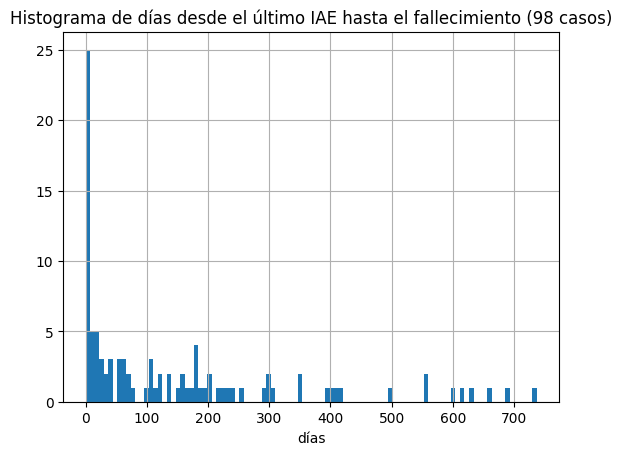

In [ ]:
plt.figure()
df_IAE_agregada[df_IAE_agregada['CAT_SUI_']==1]['MIN_DIAS_IAE_MUERTE_'].dt.days.hist(bins=100)
n_casos = df_IAE_agregada[df_IAE_agregada['CAT_SUI_']==1]['MIN_DIAS_IAE_MUERTE_'].value_counts().sum()
plt.title(f'Histograma de días desde el último IAE hasta el fallecimiento ({n_casos} casos)')
plt.xlabel('días')
plt.show()

In [ ]:
#indices = df_IAE_agregada['CEDULA'].isin(df_IAE_CDE['cedula'])
#f_IAE_agregada[~indices].shape 

personas_con_IAE_no_presentes_en_CDE(df_IAE_agregada, df_IAE_CDE)

Hay 8560 personas con IAE no presentes en CDE.


,CEDULA,Sexo,NACIMIENTO,GRUPO_EDAD_,METODO_IAE_FRECUENTE_,METODO_IAE_PREVIO_,METODO_IAE_PREVIO_2_,METODO_IAE_PREVIO_3_,IAE_PREVIO,PRESTADOR_RECODIFICADO,...,RUCAF_PRESTADOR_PUBLICO_,RUCAF_PRESTADOR_PRIVADO_,RUCAF_pais,RUCAF_departamento,RUCAF_localidad,RUCAF_cobertura,SHARPS_,SIV_,ANTIPOLIOMELITICA,COVID 19
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,Masculino,2008-02-01,17.5,Lesiones autoinfligidas,Lesiones autoinfligidas,None,None,SI,INSTITUTO ASISTENCIAL COLECTIVO IAC | DIRECCIO...,...,False,True,UY,TREINTA Y TRES,TREINTA Y TRES,Fonasa,0,1,NaN,NaN
1,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,Femenino,1991-01-01,32.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,SI,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,...,None,None,None,None,None,None,1,1,NaN,4.0
2,00133099d10f0d6d56bd2f58267ff271fd097b1682638f...,Femenino,2007-03-01,17.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,NO,ASSE - MALDONADO /DIRECCION NACIONAL DE SANIDA...,...,True,False,UY,ARTIGAS,BELLA UNION,No Fonasa,0,1,NaN,2.0
3,001eecb0c2ccec125edf01c7c069aa76d7865cae45be71...,Masculino,2005-09-01,17.5,Otros,Otros,None,None,NO,COMECA IAMPP,...,False,True,UY,TREINTA Y TRES,VERGARA,No Fonasa,0,1,NaN,2.0
4,0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f...,Femenino,1958-04-01,67.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,SI,ASSE - SALTO,...,True,False,UY,SALTO,SALTO,Fonasa,0,1,NaN,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8822,ffdda04d9cb7f61ac16abefb57d895d41381e70cc5098d...,Femenino,1998-04-01,27.5,Ahorcamiento o asfixia,Ahorcamiento o asfixia,None,None,NO,ASSE - PAYSANDU,...,True,False,UY,PAYSANDU,PORVENIR,No Fonasa,0,1,NaN,2.0
8823,ffe42d723da45d0e54737c67fccc747dcc8aceb73075fb...,Femenino,2009-05-01,17.5,Lesiones autoinfligidas,Lesiones autoinfligidas,None,None,SI,COMERO,...,False,True,UY,ROCHA,ROCHA,Fonasa,0,1,NaN,1.0
8824,fff6eeeb39dc05fc78a98f367f478045ccf8835a538565...,Masculino,1965-11-01,57.5,Ingesta de Medicamentos,Ingesta de Medicamentos,Ingesta de Medicamentos,None,SI,CASMU,...,False,True,UY,MONTEVIDEO,MONTEVIDEO,Fonasa,0,0,NaN,NaN
8825,fff70f241b7a38806c1580fb5d8077c97d84bc6256b0ae...,Femenino,1995-07-01,27.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,NO,ASSE - SD,...,None,None,None,None,None,None,0,0,NaN,NaN


In [ ]:
indices = df_IAE_CDE['cedula'].isin(df_IAE_agregada['CEDULA'])
personas = df_IAE_CDE[~indices]

In [ ]:
personas_en_CDE_sin_IAE(df_IAE_agregada, df_IAE_CDE)

Hay 2 personas en CDE que no están en la base de IAE.


,cedula,fecha_defuncion,causa_basica_muerte_valor,causa_basica_muerte_descripcion,lugar_ocurrencia,lugar_ocurrencia_detalle,departamento_ocurrencia,edad_fallecimiento_calculada,edad_fallecimiento_digitada,CAT_SUI_,CAT_MCEXSUI_,grupo edades_
37,21c2eedd94ddf081962ebffb62052a32f17e67afb77f31...,2023-03-19,C800,"TUMOR MALIGNO, DE SITIO PRIMARIO DESCONOCIDO, ...",CENTRO ASISTENCIAL,NaN,DU,62.0,62.0,0,0,62.5
172,acb54dd66c3165a41def528880af8e16e98da8ece2c6d9...,2023-06-25,X700,LESIÓN AUTOINFLIGIDA INTENCIONALMENTE POR AHOR...,CENTRO ASISTENCIAL,NaN,MO,37.0,37.0,1,0,37.5


In [ ]:
df_IAE_agregada[df_IAE_agregada['PRESTADOR_PUBLICO_']==1]['IAE_en_CDE_'].value_counts()

IAE_en_CDE_
0    3831
1     123
Name: count, dtype: int64

In [ ]:
if dataset==2:
    indices = df_IAE_agregada['CEDULA'].isin(df_IAE_EH['cedula'])
    df_IAE_agregada[~indices].shape 

In [ ]:
df_IAE_agregada[df_IAE_agregada['MIN_DIAS_IAE_MUERTE_']< pd.Timedelta(days=0)]

,CEDULA,Sexo,NACIMIENTO,GRUPO_EDAD_,METODO_IAE_FRECUENTE_,METODO_IAE_PREVIO_,METODO_IAE_PREVIO_2_,METODO_IAE_PREVIO_3_,IAE_PREVIO,PRESTADOR_RECODIFICADO,...,RUCAF_PRESTADOR_PUBLICO_,RUCAF_PRESTADOR_PRIVADO_,RUCAF_pais,RUCAF_departamento,RUCAF_localidad,RUCAF_cobertura,SHARPS_,SIV_,ANTIPOLIOMELITICA,COVID 19


In [ ]:
df_IAE_agregada['IAE_en_CDE_'].value_counts()

IAE_en_CDE_
0    8560
1     267
Name: count, dtype: int64

In [ ]:
df_IAE_agregada.set_index('FECHA_DEFUNCION').resample('W').size()

FECHA_DEFUNCION
2023-02-12    3
2023-02-19    1
2023-02-26    0
2023-03-05    1
2023-03-12    2
             ..
2025-09-07    1
2025-09-14    3
2025-09-21    3
2025-09-28    2
2025-10-05    2
Length: 139, dtype: int64

In [ ]:
if dataset==2:
    #conteo_semanal_defunciones = df_IAE_agregada[df_IAE_agregada['CAT_SUI_']==1].set_index('FECHA_DEFUNCION').resample('W').size()

    #plt.figure()
    #conteo_semanal_defunciones.plot()
    #plt.xlabel("Fecha")
    #plt.ylabel("Cantidad")
    #plt.title("Cantidad de fallecimientos por semana")
    #plt.xticks(rotation=45)
    #plt.show()

    graficar_segun_fecha(df_IAE_agregada,'FECHA_DEFUNCION','W')

In [ ]:
df_IAE_agregada.head()

,CEDULA,Sexo,NACIMIENTO,GRUPO_EDAD_,METODO_IAE_FRECUENTE_,METODO_IAE_PREVIO_,METODO_IAE_PREVIO_2_,METODO_IAE_PREVIO_3_,IAE_PREVIO,PRESTADOR_RECODIFICADO,...,RUCAF_PRESTADOR_PUBLICO_,RUCAF_PRESTADOR_PRIVADO_,RUCAF_pais,RUCAF_departamento,RUCAF_localidad,RUCAF_cobertura,SHARPS_,SIV_,ANTIPOLIOMELITICA,COVID 19
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,Masculino,2008-02-01,17.5,Lesiones autoinfligidas,Lesiones autoinfligidas,None,None,SI,INSTITUTO ASISTENCIAL COLECTIVO IAC | DIRECCIO...,...,False,True,UY,TREINTA Y TRES,TREINTA Y TRES,Fonasa,0,1,NaN,NaN
1,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,Femenino,1991-01-01,32.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,SI,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,...,None,None,None,None,None,None,1,1,NaN,4.0
2,00133099d10f0d6d56bd2f58267ff271fd097b1682638f...,Femenino,2007-03-01,17.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,NO,ASSE - MALDONADO /DIRECCION NACIONAL DE SANIDA...,...,True,False,UY,ARTIGAS,BELLA UNION,No Fonasa,0,1,NaN,2.0
3,001eecb0c2ccec125edf01c7c069aa76d7865cae45be71...,Masculino,2005-09-01,17.5,Otros,Otros,None,None,NO,COMECA IAMPP,...,False,True,UY,TREINTA Y TRES,VERGARA,No Fonasa,0,1,NaN,2.0
4,0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f...,Femenino,1958-04-01,67.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,SI,ASSE - SALTO,...,True,False,UY,SALTO,SALTO,Fonasa,0,1,NaN,3.0


In [ ]:
#df_IAE_agregada['DIAS_PROMEDIO_INTENTOS_'].unique()
mostrar_unicos(df_IAE_agregada,'DIAS_PROMEDIO_INTENTOS_')

DIAS_PROMEDIO_INTENTOS_ tiene 511 valores únicos.
[         nan 329.          80.         248.         137.2
 227.5        303.         170.         126.          77.5
  19.           2.          34.          21.         617.
   8.          37.         217.         427.         144.5
 128.66666667 218.         128.           1.         278.
  45.         181.          15.         380.           0.
 169.         140.         127.         174.          16.5
   9.         216.         145.33333333  35.          24.
 512.          14.          33.          58.         136.
 345.         162.          59.66666667 164.         354.
 205.         306.5        117.         196.          90.
 534.          41.5        202.         207.         120.
  29.         132.5        273.         150.         219.
  30.         401.         182.         173.          24.8
 157.         106.5        352.          23.         298.
 183.         115.         212.         289.         308.
   6.         266

In [ ]:
np.sum(df_IAE_agregada['IAE_en_CDE_']==1)

np.int64(267)

In [ ]:
# Cuadro 2A en el informe
df_IAE_agregada['NUMERO_INTENTOS_'].value_counts()

NUMERO_INTENTOS_
1     7721
2      810
3      193
4       60
5       22
6       13
9        3
10       2
7        2
8        1
Name: count, dtype: int64

In [ ]:
mostrar_frecuencias(df_IAE_agregada, 'IAE_PREVIO')

IAE_PREVIO
SI              4275
NO              3137
NO SE INDICA    1415
Name: count, dtype: int64


In [ ]:
#df_IAE_agregada['IAE_PREVIO_CORREGIDO' ] = df_IAE_agregada['IAE_PREVIO'].copy()
#df_IAE_agregada.loc[(df_IAE_agregada["IAE_PREVIO_CORREGIDO"] == "NO SE INDICA") & (df_IAE_agregada["NUMERO_INTENTOS_"] > 0), "IAE_PREVIO_CORREGIDO"] = "SI"

df_IAE_agregada = agregar_IAE_PREVIO_corregido(df_IAE_agregada)

In [ ]:
df_IAE['IAE PREVIO'].shape, df_IAE_agregada['IAE_PREVIO'].shape

((10417,), (8827,))

In [ ]:
df_IAE['IAE PREVIO'].value_counts().sum()

np.int64(10417)

In [ ]:
df_IAE_agregada['IAE_PREVIO'].value_counts().sum()

np.int64(8827)

In [ ]:
df_IAE_agregada['IAE_PREVIO_CORREGIDO'].value_counts()

IAE_PREVIO_CORREGIDO
SI              4356
NO              3137
NO SE INDICA    1334
Name: count, dtype: int64

In [ ]:
df_IAE_agregada.loc[df_IAE_agregada['IAE_PREVIO']=='NO SE INDICA', 'IAE_en_CDE_'].value_counts()

IAE_en_CDE_
0    1356
1      59
Name: count, dtype: int64

In [ ]:
df_IAE_agregada.loc[df_IAE_agregada['IAE_PREVIO']=='NO SE INDICA', 'NUMERO_INTENTOS_'].value_counts()

NUMERO_INTENTOS_
1    1334
2      66
3      11
4       2
5       1
9       1
Name: count, dtype: int64

In [ ]:
df_IAE_agregada.loc[df_IAE_agregada['IAE_PREVIO_CORREGIDO']=='NO SE INDICA', 'IAE_en_CDE_'].value_counts()

IAE_en_CDE_
0    1278
1      56
Name: count, dtype: int64

In [ ]:
df_IAE_agregada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8827 entries, 0 to 8826
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype          
---  ------                       --------------  -----          
 0   CEDULA                       8827 non-null   object         
 1   Sexo                         8827 non-null   object         
 2   NACIMIENTO                   8826 non-null   datetime64[ns] 
 3   GRUPO_EDAD_                  8826 non-null   float64        
 4   METODO_IAE_FRECUENTE_        8827 non-null   object         
 5   METODO_IAE_PREVIO_           8827 non-null   object         
 6   METODO_IAE_PREVIO_2_         1106 non-null   object         
 7   METODO_IAE_PREVIO_3_         296 non-null    object         
 8   IAE_PREVIO                   8827 non-null   object         
 9   PRESTADOR_RECODIFICADO       8827 non-null   object         
 10  PRESTADOR_PUBLICO_           8827 non-null   bool           
 11  PRESTADOR_PRIVADO_           8

In [ ]:
for atributo in df_IAE_agregada.keys():
    mostrar_valores_nulos(df_IAE_agregada,atributo)
    mostrar_unicos(df_IAE_agregada,atributo)
    mostrar_frecuencias(df_IAE_agregada,atributo)

CEDULA tiene 0 valores nulos
CEDULA tiene 8827 valores únicos.
['0003596f1bde95098ff48b86d0561cb0498b93576221e33bb3da1bf5fabf0ee2'
 '00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db8d78c72df7ea548a22'
 '00133099d10f0d6d56bd2f58267ff271fd097b1682638fc7405967ed68fbeff5' ...
 'fff6eeeb39dc05fc78a98f367f478045ccf8835a538565f47ba0949106157136'
 'fff70f241b7a38806c1580fb5d8077c97d84bc6256b0aefb96ce7f4d04b484c2'
 'fff9a612ad60860b9c3be2ca6b24e6d338b2a8f62b11f7602b4f14707c32dfd5']
CEDULA
fff9a612ad60860b9c3be2ca6b24e6d338b2a8f62b11f7602b4f14707c32dfd5    1
0003596f1bde95098ff48b86d0561cb0498b93576221e33bb3da1bf5fabf0ee2    1
00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db8d78c72df7ea548a22    1
00133099d10f0d6d56bd2f58267ff271fd097b1682638fc7405967ed68fbeff5    1
001eecb0c2ccec125edf01c7c069aa76d7865cae45be71efe20ec50640eb6686    1
                                                                   ..
0064e230db26bdf9da80017cc9f69dd7200a028c856939cd19ed154d10705493    1
005a7f74e52461b66a89fd5d41a

In [ ]:
#for atributo in df_IAE_agregada.keys():
#    if 'FECHA' in atributo or 'REGISTRO' == atributo:
#        mostrar_rango(df_IAE_agregada,atributo)

## Guardar la base de datos agregada por persona

In [ ]:
nombre_procesada = f'IAE_agregada_entrega{dataset}_{timestamp}.csv' 
df_IAE_agregada.to_csv(nombre_procesada)